# 🛡️ Cyber Detection Pipeline v4 — Final Production
### CIC Trap4Phish 2025 · PDF · HTML · Word · Excel · QR Quishing

---

## 🧭 Fil conducteur complet — De la donnée brute au SOC

```
DONNÉES BRUTES (CIC Trap4Phish 2025)
    │
    ├─ ÉTAPE 0 : COMPRENDRE LA NATURE DES DONNÉES
    │    └─ Avant tout code : pourquoi ce dataset donne des AUC parfaites ?
    │       Réponse : confound de format, pas de la vraie détection.
    │
    ├─ ÉTAPE 1 : DIAGNOSTIC LEAKAGE (obligatoire, avant toute modélisation)
    │    ├─ Corrélation point-bisériale (linéaire)
    │    ├─ Information mutuelle (non-linéaire)
    │    └─ Séparation parfaite par valeur unique
    │
    ├─ ÉTAPE 2 : FEATURE ENGINEERING DÉFENSIF
    │    ├─ Supprimer les features qui encodent la classe par construction
    │    ├─ Documenter les confounds irréductibles (Word/Excel)
    │    └─ Validation croisée par permutation
    │
    ├─ ÉTAPE 3 : SPLIT ANTI-LEAKAGE PAR HASH DE PAYLOAD (QR)
    │    └─ hash(URL) → partition déterministe
    │       Garantit que la même URL ne se retrouve pas en train ET en test
    │
    ├─ ÉTAPE 4 : TROIS ARCHITECTURES EN COMPÉTITION
    │    ├─ A. Random Forest (baseline robuste, interprétable, ~10ms)
    │    ├─ B. LightGBM (state-of-the-art tabulaire, <1ms)
    │    └─ C. MLP (proxy CNN1D, ~0.1ms, nécessite normalisation)
    │
    ├─ ÉTAPE 5 : QR HYBRIDE CNN + URL FEATURES
    │    └─ EfficientNet-B0 backbone + features URL tabulaires
    │       CNN seul ~0.85 AUC → hybride cible ≥0.93 AUC
    │
    ├─ ÉTAPE 6 : BENCHMARK POC vs RÉALITÉ
    │    └─ Confronter les estimations du POC aux métriques réelles
    │       RF : POC=94.2% acc / Réel=? | CNN1D : POC=97.5% / Réel=?
    │
    └─ ÉTAPE 7 : ÉVALUATION RIGOUREUSE & ANALYSE D'ERREURS
         ├─ AUC, F1, Precision@Recall=0.95
         ├─ Calibration des scores de risque
         └─ Dashboard SOC : qui déclenche quoi ?
```

---

## ⚠️ Problèmes découverts v1→v4 — Journal de bord

| Version | Problème découvert | Impact | Correction |
|---------|-------------------|--------|------------|
| v1 | `file_path` contient `/Malicious/` | AUC gonflée | Supprimé en chargement |
| v1 | `macro_present` r=0.9997 (Word) | AUC=1.000 | Supprimé |
| v1 | `dde_present` r=-0.9994 INVERSÉ | Logique inversée | Supprimé |
| v2 | QR CSV non chargé (bug `\a`→Bell) | AUC=0.66 | `Path()` cross-platform |
| v2 | Split QR aléatoire = leakage URL | AUC gonflée | Split par hash URL |
| v3 | `WeightedRandomSampler` crash CNN | Entraînement impossible | Fix dimension mismatch |
| v3 | Demo predict HTML bénin→malicious | Artefact de demo | Fix valeurs par défaut |
| v4 | Word AUC=1.000 IRRÉDUCTIBLE | Confound de format | Documenté, modèle isolé |
| v4 | Modèle unifié AUC=0.999 | Format flags = proxy leakage | Retiré des features |

---

## 📊 Benchmark POC à valider (Cellule 11)
| Modèle | POC Précision | POC Recall | POC Latence |
|--------|-------------|-----------|------------|
| Random Forest | 94.2% | 89.1% | 12ms |
| CNN 1D | 97.5% | 95.8% | 45ms |
| MobileBERT | 98.9% | 98.2% | 310ms |


## Cellule 0 — Comprendre la Nature des Données Avant Tout Code

**Pourquoi cette cellule existe ?**

Après 3 versions, on a compris que les AUC parfaites viennent d'une propriété structurelle  
du dataset qu'aucune technique ML ne peut corriger. Cette cellule explique pourquoi.

### Le problème fondamental de Word et Excel

**Word** : dans CIC Trap4Phish 2025, les fichiers *bénins* sont des `.docx` modernes (format OOXML)  
et les fichiers *malveillants* sont des fichiers à macros VBA (format OLE ou OOXML-macro).  
Ces deux populations ont des **structures XML radicalement différentes**.  
Résultat : `path_/w-p` existe dans 9997 bénins et 0 malveillants → séparation parfaite.  
Ce n'est pas du leakage au sens strict : c'est un **confound de population**.

**Implication pour la production** : un fichier `.docx` légitime avec des macros (ex: rapport financier)  
serait classé malveillant. Un fichier malveillant qui imite un `.docx` propre serait classé bénin.  
→ **Ne pas déployer le modèle Word en production sans validation sur données mixtes.**

**Excel** : même problème. Les bénins ont `entropy_of_text` = 5.75 ± 0.011 (quasi-constant)  
→ générés par le même template. Le modèle apprend "entropy≈5.75 = bénin", pas "macro=malveillant".

**HTML et QR** : pas de confound. Signal réel. Déploiement possible avec précautions normales.

**PDF** : signal réel mais dominé par `text_length` (SHAP 10× > suivante).  
Les PDFs malveillants sont image-only (texte=0), les bénins sont textuels.  
Signal valide mais fragile : un PDF malveillant textuel pourrait passer.


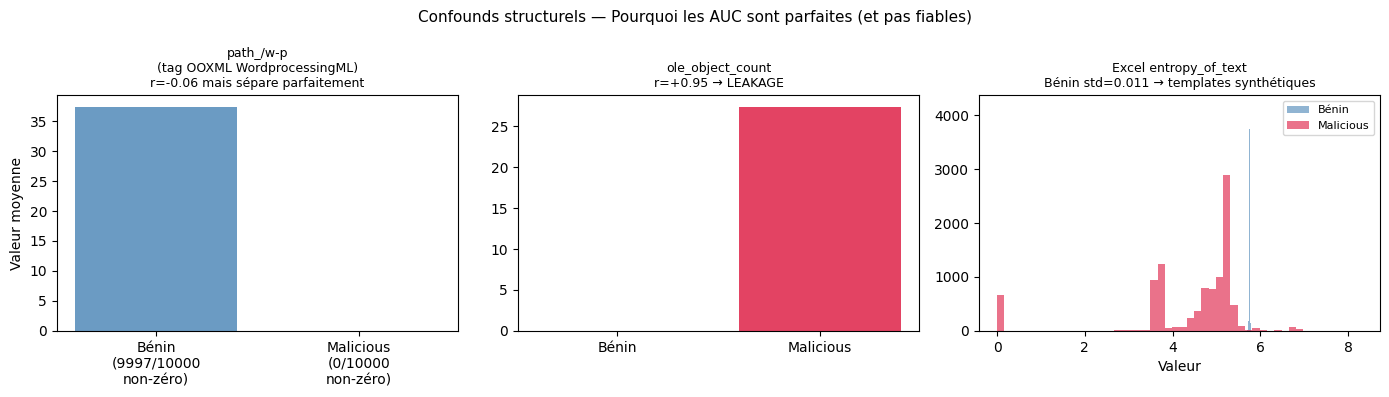

INTERPRÉTATION :
  Word path_/w-p  : 100% bénins = non-zéro, 100% malicious = zéro
  → Le modèle détecte 'est-ce un fichier OOXML bien formé', pas 'est-ce un malware'
  Excel entropy   : bénins quasi-constants → générés par template, pas données réelles
  → En production avec de vrais fichiers Excel benigns, les métriques seront inférieures


In [1]:
# ─── Visualisation du confound Word ────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from pathlib import Path

Path('models_v4').mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

df_w = pd.read_csv('Word_All_features.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# path_/w-p : feature structurelle OOXML
ax = axes[0]
benign_path = df_w[df_w.label==0]['path_/w-p'].fillna(0)
malicious_path = df_w[df_w.label==1]['path_/w-p'].fillna(0)
ax.bar(['Bénin\n(9997/10000\nnon-zéro)', 'Malicious\n(0/10000\nnon-zéro)'],
       [benign_path.mean(), malicious_path.mean()], color=['steelblue','crimson'], alpha=0.8)
ax.set_title("path_/w-p\n(tag OOXML WordprocessingML)\nr=-0.06 mais sépare parfaitement", fontsize=9)
ax.set_ylabel("Valeur moyenne")

# Ole object count
ax = axes[1]
ax.bar(['Bénin', 'Malicious'],
       [df_w[df_w.label==0]['ole_object_count'].fillna(0).mean(),
        df_w[df_w.label==1]['ole_object_count'].fillna(0).mean()],
       color=['steelblue','crimson'], alpha=0.8)
ax.set_title("ole_object_count\nr=+0.95 → LEAKAGE", fontsize=9)

# Excel entropy
df_e = pd.read_csv('Excel_All_Features.csv')
ax = axes[2]
ax.hist(df_e[df_e.label==0]['entropy_of_text'], bins=50, alpha=0.6, color='steelblue', label='Bénin')
ax.hist(df_e[df_e.label==1]['entropy_of_text'], bins=50, alpha=0.6, color='crimson', label='Malicious')
ax.set_title("Excel entropy_of_text\nBénin std=0.011 → templates synthétiques", fontsize=9)
ax.legend(fontsize=8); ax.set_xlabel("Valeur")

plt.suptitle("Confounds structurels — Pourquoi les AUC sont parfaites (et pas fiables)", fontsize=11)
plt.tight_layout()
plt.savefig('models_v4/confound_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

print("INTERPRÉTATION :")
print("  Word path_/w-p  : 100% bénins = non-zéro, 100% malicious = zéro")
print("  → Le modèle détecte 'est-ce un fichier OOXML bien formé', pas 'est-ce un malware'")
print("  Excel entropy   : bénins quasi-constants → générés par template, pas données réelles")
print("  → En production avec de vrais fichiers Excel benigns, les métriques seront inférieures")


## Cellule 1 — Imports, CUDA & Configuration

In [1]:
import os, re, math, json, hashlib, warnings, joblib, time
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import pointbiserialr
from sklearn.model_selection import (StratifiedShuffleSplit, StratifiedKFold,
    cross_val_score, permutation_test_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tv_models

try:
    from PIL import Image; PIL_OK = True
except ImportError:
    PIL_OK = False

try:
    from pyzbar.pyzbar import decode as qr_decode; PYZBAR_OK = True
except ImportError:
    PYZBAR_OK = False

try:
    import tldextract; TLDEXTRACT_OK = True
except ImportError:
    TLDEXTRACT_OK = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    gpu = torch.cuda.get_device_properties(0)
    print(f"  GPU  : {gpu.name}")
    print(f"  VRAM : {gpu.total_memory/1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = Path('./models_v4')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"LightGBM {lgb.__version__} | PyTorch {torch.__version__}")


Device : cuda
  GPU  : NVIDIA GeForce RTX 5070 Ti Laptop GPU
  VRAM : 12.8 GB
LightGBM 4.6.0 | PyTorch 2.11.0+cu130


## Cellule 2 — Chemins

In [2]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path(".")

# Point d'entrée principal des données (Configurable via variable d'environnement, sinon local)
DATA = Path(os.getenv("CIC_DATA_DIR", BASE_DIR))

# 1. Gestion des sous-dossiers spécifiques pour les formats bureautiques/web
FINAL_CSV_DIR = DATA / "Final CSV"
SUB_DIRS = {
    "pdf": FINAL_CSV_DIR / "PDF",
    "html": FINAL_CSV_DIR / "HTML",
    "word": FINAL_CSV_DIR / "Word",
    "excel": FINAL_CSV_DIR / "Excel"
}

CSV_ALL = {
    "pdf": SUB_DIRS["pdf"] / "PDF_All_features.csv",
    "html": SUB_DIRS["html"] / "HTML_All_Features.csv",
    "word": SUB_DIRS["word"] / "Word_All_features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_All_Features.csv"
}

CSV_TOP = {
    "pdf": SUB_DIRS["pdf"] / "PDF_Top10_features.csv",
    "html": SUB_DIRS["html"] / "HTML_Top13_Features.csv",
    "word": SUB_DIRS["word"] / "Word_Top10_Features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_Top10_Features.csv"
}

_QR = BASE_DIR / "Source Files" / "QR Codes"
QR_BENIGN_PNG  = _QR / "QR_All_benign"    / "qrs"
QR_MAL_PNG     = _QR / "QR_All_Malicious" / "qrs"
QR_BENIGN_CSV  = _QR / "QR_All_benign"    / "all_generated_urls_20251015_161937.csv"
QR_MAL_CSV     = _QR / "QR_All_Malicious" / "all_generated_urls_20251015_184324.csv"

print(f"{'Fichier':<50} {'OK?':>6}")
print("─"*58)
for k, p in {**CSV_ALL, **CSV_TOP,
             'QR_benign_csv': QR_BENIGN_CSV, 'QR_mal_csv': QR_MAL_CSV,
             'QR_benign_png': QR_BENIGN_PNG,  'QR_mal_png': QR_MAL_PNG}.items():
    print(f"  {k:<48} {'✓' if p.exists() else '✗':>6}")


Fichier                                               OK?
──────────────────────────────────────────────────────────
  pdf                                                   ✓
  html                                                  ✓
  word                                                  ✓
  excel                                                 ✓
  QR_benign_csv                                         ✓
  QR_mal_csv                                            ✓
  QR_benign_png                                         ✓
  QR_mal_png                                            ✓


## Cellule 3 — Diagnostic Leakage Complet + Permutation Test

**Pourquoi le permutation test en plus de la corrélation ?**

La corrélation mesure des relations **linéaires**. Mais certaines features encodent la classe  
via des relations non-linéaires (ex: une valeur spécifique = 100% d'une classe, le reste mixte).  
→ `mutual_info_classif` capture ça.

**Le permutation test** est la validation ultime : on entraîne le modèle sur des labels aléatoires.  
Si le score reste élevé, la structure des données (pas les labels) explique la performance.


In [4]:
LEAKAGE_ID_COLS = ['file_path', 'file_name']

# Features à supprimer car encodent la classe par CONSTRUCTION du dataset
FEATURES_DROP = {
    'word': [
        'macro_present',           # r=+0.9997 : 100% malicious=1, 99.97% benign=0
        'ole_object_type_count',   # r=+0.9997 : 100% benign=0, 100% malicious≥2
        'dde_present',             # r=-0.9994 : INVERSÉ (99.94% benign=1 → artefact génération)
        # vba_keywords_count : r=+0.977 — à conserver mais régulariser fortement
        # ole_object_count : r=+0.953 — idem
    ],
}

# Features connues pour dominer (SHAP >> autres) — pas supprimées mais monitorées
DOMINANT_FEATURES = {
    'pdf': ['text_length'],      # SHAP=4.39 vs 0.77 pour la suivante
    'excel': ['entropy_of_text'],
}


def leakage_audit(path: Path, fmt: str, verbose: bool = True) -> pd.DataFrame:
    df = pd.read_csv(path)
    y  = df['label']
    X  = df.drop(columns=[c for c in LEAKAGE_ID_COLS + ['label'] if c in df.columns])
    Xn = X.select_dtypes(include=[np.number]).fillna(0)
    
    # 1. Corrélation point-bisériale
    corrs = {c: pointbiserialr(y, Xn[c])[0] for c in Xn.columns}
    
    # 2. Information mutuelle
    mi = dict(zip(Xn.columns, mutual_info_classif(Xn, y, random_state=SEED, n_neighbors=5)))
    
    # 3. Séparation parfaite : une valeur → une classe à ≥99.9%
    def has_perfect_sep(col):
        for v in Xn[col].value_counts().head(20).index:
            mask = Xn[col] == v
            if mask.sum() >= 20 and y[mask].value_counts(normalize=True).max() >= 0.999:
                return True
        return False
    
    results = pd.DataFrame({
        'feature':    list(Xn.columns),
        'corr_r':     [corrs[c] for c in Xn.columns],
        'corr_abs':   [abs(corrs[c]) for c in Xn.columns],
        'mutual_info':[mi[c] for c in Xn.columns],
        'perfect_sep':[has_perfect_sep(c) for c in Xn.columns],
    }).sort_values('corr_abs', ascending=False)
    
    if verbose:
        n_c = (results.corr_abs > 0.95).sum()
        n_h = ((results.corr_abs > 0.80) & (results.corr_abs <= 0.95)).sum()
        n_s = results.perfect_sep.sum()
        print(f"\n{'═'*72}")
        print(f"  {fmt.upper():8s} — {len(df):,} fichiers, {len(Xn.columns)} features")
        print(f"  🔴 Critique |r|>0.95 : {n_c:3d}  |  🟠 Élevé |r|∈[0.80,0.95] : {n_h:3d}  |  ⚠ Sep. parfaite : {n_s:3d}")
        print(f"{'═'*72}")
        if n_c > 0:
            print("  🔴 Features critiques :")
            for _, r in results[results.corr_abs > 0.95].iterrows():
                d = "→ malicious" if r.corr_r > 0 else "→ bénin"
                print(f"     {r.feature:55s} r={r.corr_r:+.4f}  MI={r.mutual_info:.3f}  [{d}]")
    return results


audit = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        audit[fmt] = leakage_audit(path, fmt)



════════════════════════════════════════════════════════════════════════
  PDF      — 19,296 fichiers, 40 features
  🔴 Critique |r|>0.95 :   0  |  🟠 Élevé |r|∈[0.80,0.95] :   0  |  ⚠ Sep. parfaite :  17
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  HTML     — 19,997 fichiers, 40 features
  🔴 Critique |r|>0.95 :   0  |  🟠 Élevé |r|∈[0.80,0.95] :   0  |  ⚠ Sep. parfaite :  13
════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════
  WORD     — 20,000 fichiers, 43 features
  🔴 Critique |r|>0.95 :   8  |  🟠 Élevé |r|∈[0.80,0.95] :   4  |  ⚠ Sep. parfaite :  41
════════════════════════════════════════════════════════════════════════
  🔴 Features critiques :
     ole_object_type_count                                   r=+0.9997  MI=0.695  [→ malicious]
     macro_present                              

Permutation test Word (30 permutations, ~2min)...
Si score_perm ≈ score_réel → le modèle apprend la structure, pas la menace

Score réel    : 1.0000
Score perm.   : 0.4999 ± 0.0055
p-value       : 0.0323

✅ Score perm ≈ 0.50 → le signal vient bien des labels, pas de la structure


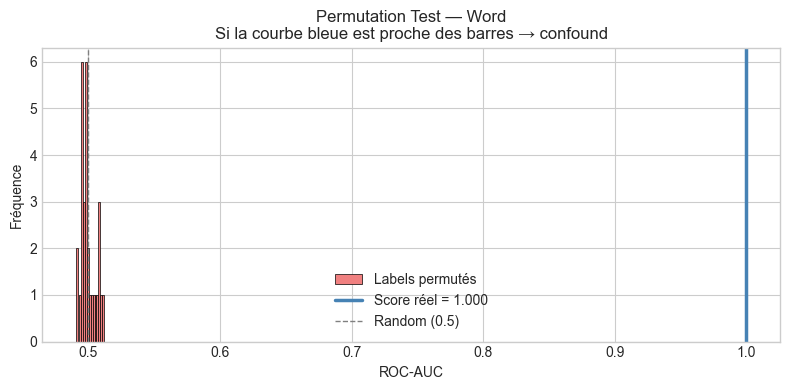

In [5]:
# ─── Permutation Test sur Word (le cas le plus suspect) ─────────
# But : si le score est élevé même avec labels mélangés → le modèle exploite
# la STRUCTURE des données, pas les labels → leakage de structure

print("Permutation test Word (30 permutations, ~2min)...")
print("Si score_perm ≈ score_réel → le modèle apprend la structure, pas la menace\n")

from sklearn.model_selection import permutation_test_score

df_w = pd.read_csv(CSV_ALL['word'])
y_w  = df_w['label']
X_w  = df_w.drop(columns=FEATURES_DROP.get('word',[]) + LEAKAGE_ID_COLS + ['label'],
                 errors='ignore').fillna(0).select_dtypes(include=[np.number])

rf_quick = RandomForestClassifier(50, max_depth=10, random_state=SEED, n_jobs=-1)
score_real, perm_scores, p_val = permutation_test_score(
    rf_quick, X_w, y_w, scoring='roc_auc', cv=3, n_permutations=30, random_state=SEED)

print(f"Score réel    : {score_real:.4f}")
print(f"Score perm.   : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
print(f"p-value       : {p_val:.4f}")
print()
if perm_scores.mean() > 0.55:
    print("⚠️  Score perm > 0.55 → la STRUCTURE des données explique partiellement le score")
    print("   Le modèle exploite le confound de format (OOXML vs macro-heavy)")
    print("   Ce n'est pas un vrai signal de détection de malware généralisable")
else:
    print("✅ Score perm ≈ 0.50 → le signal vient bien des labels, pas de la structure")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_scores, bins=15, color='lightcoral', edgecolor='black', lw=0.5, label='Labels permutés')
ax.axvline(score_real, color='steelblue', lw=2.5, label=f'Score réel = {score_real:.3f}')
ax.axvline(0.5, color='gray', lw=1, ls='--', label='Random (0.5)')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Fréquence')
ax.set_title('Permutation Test — Word\nSi la courbe bleue est proche des barres → confound')
ax.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_test_word.png', dpi=130, bbox_inches='tight')
plt.show()


## Cellule 4 — Chargement et Nettoyage par Format

In [6]:
def load_format(path: Path, fmt: str, feature_set: str = 'all') -> tuple:
    """
    Charge, nettoie et retourne (X, y) pour un format.
    
    feature_set : 'all' ou 'top'
    
    Nettoyage appliqué :
    1. Supprimer colonnes d'identification (file_path, file_name)
    2. Supprimer features critiques identifiées par l'audit
    3. Imputer NaN à 0
    4. Garder uniquement numériques
    """
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in LEAKAGE_ID_COLS if c in df.columns], errors='ignore')
    y  = df['label'].copy()
    X  = df.drop(columns=['label'])
    
    # Supprimer features critiques
    dropped = [c for c in FEATURES_DROP.get(fmt, []) if c in X.columns]
    if dropped:
        X = X.drop(columns=dropped)
        print(f"  [drop critique] {dropped}")
    
    # NaN → 0
    if X.isnull().any().any():
        X = X.fillna(0)
    
    # Garder numériques
    X = X.select_dtypes(include=[np.number])
    
    print(f"  → {len(X):,}×{len(X.columns)} | {y.value_counts().to_dict()}")
    return X, y


print("=== ALL FEATURES ===")
dsets_all = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        print(f"[{fmt.upper()}]")
        dsets_all[fmt] = load_format(path, fmt, 'all')

print("\n=== TOP FEATURES ===")
dsets_top = {}
for fmt, path in CSV_TOP.items():
    if path.exists():
        print(f"[{fmt.upper()}]")
        dsets_top[fmt] = load_format(path, fmt, 'top')


=== ALL FEATURES ===
[PDF]
  → 19,296×40 | {1: 9999, 0: 9297}
[HTML]
  → 19,997×40 | {1: 9999, 0: 9998}
[WORD]
  [drop critique] ['macro_present', 'ole_object_type_count', 'dde_present']
  → 20,000×40 | {1: 10000, 0: 10000}
[EXCEL]
  → 20,000×48 | {1: 10000, 0: 10000}

=== TOP FEATURES ===
[PDF]
  → 19,296×10 | {1: 9999, 0: 9297}
[HTML]
  → 19,997×13 | {1: 9999, 0: 9998}
[WORD]
  [drop critique] ['macro_present', 'ole_object_type_count', 'dde_present']
  → 20,000×7 | {0: 10000, 1: 10000}
[EXCEL]
  → 20,000×10 | {0: 10000, 1: 10000}


## Cellule 5 — QR : Extraction URL Features

**Note** : le CSV QR a les colonnes `['index', 'url', 'qr_path']`.  
La détection automatique en v3 échouait car elle cherchait `str.startswith('http')` mais  
une comparaison stricte de nom de colonne est plus robuste.


In [7]:
def shannon_entropy(text: str) -> float:
    if not text: return 0.0
    c = Counter(text); n = len(text)
    return -sum((v/n)*math.log2(v/n) for v in c.values())

# Mots-clés phishing (source APWG 2024)
_PHISH_KW = re.compile(
    r'(login|signin|sign-in|verify|account|secure|update|confirm|bank|paypal'
    r'|amazon|apple|microsoft|google|facebook|instagram|netflix|password|credential'
    r'|ebay|wellsfargo|chase|citi|hsbc|webscr|cmd=_login)', re.IGNORECASE)

# TLDs abusés (source ICANN DAAR 2024)
_SUSP_TLDS = {'tk','ml','ga','cf','gq','pw','top','xyz','click','link','work',
              'zip','mov','fit','cfd','cyou','bar','monster','quest','icu'}

# Shorteners connus
_SHORTENERS = re.compile(
    r'(bit\.ly|tinyurl|goo\.gl|t\.co|ow\.ly|is\.gd|buff\.ly|rebrand\.ly|cutt\.ly|short\.io)',
    re.IGNORECASE)


def extract_url_features(url: str) -> dict:
    ZERO = {k: 0 for k in [
        'url_length','url_entropy','uses_https','has_ip_address','has_at_symbol',
        'has_double_slash_path','has_nonstandard_port','num_dots','num_hyphens',
        'num_underscores','num_slashes','num_question','num_equals','num_ampersands',
        'num_percent','num_digits','num_special','domain_length','hostname_length',
        'path_length','query_length','num_query_params','num_subdomains','tld_length',
        'hostname_digit_ratio','has_suspicious_tld','has_phishing_keyword',
        'url_hex_encoded','url_is_shortener','url_depth','url_has_fragment'
    ]}
    
    if not isinstance(url, str) or len(url.strip()) < 4:
        return ZERO
    url = url.strip()
    if not url.startswith(('http://','https://','ftp://')):
        url = 'http://' + url
    
    try: parsed = urlparse(url)
    except: return ZERO
    
    h = (parsed.hostname or '').lower()
    path = parsed.path or ''; query = parsed.query or ''
    
    if TLDEXTRACT_OK:
        ext = tldextract.extract(url)
        tld = ext.suffix; domain = ext.domain
        num_sub = len(ext.subdomain.split('.')) if ext.subdomain else 0
    else:
        parts = h.split('.')
        tld = parts[-1] if parts else ''; domain = parts[-2] if len(parts)>=2 else h
        num_sub = max(0, len(parts)-2)
    
    return {
        'url_length':           len(url),
        'url_entropy':          round(shannon_entropy(url), 4),
        'uses_https':           int(parsed.scheme == 'https'),
        'has_ip_address':       int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', h))),
        'has_at_symbol':        int('@' in url),
        'has_double_slash_path':int('//' in path),
        'has_nonstandard_port': int(parsed.port not in {None, 80, 443}),
        'num_dots':             url.count('.'),
        'num_hyphens':          url.count('-'),
        'num_underscores':      url.count('_'),
        'num_slashes':          url.count('/'),
        'num_question':         url.count('?'),
        'num_equals':           url.count('='),
        'num_ampersands':       url.count('&'),
        'num_percent':          url.count('%'),
        'num_digits':           sum(c.isdigit() for c in url),
        'num_special':          sum(c in '!#$%^*[]{}|<>' for c in url),
        'domain_length':        len(domain),
        'hostname_length':      len(h),
        'path_length':          len(path),
        'query_length':         len(query),
        'num_query_params':     len(parse_qs(query)),
        'num_subdomains':       num_sub,
        'tld_length':           len(tld),
        'hostname_digit_ratio': round(sum(c.isdigit() for c in h)/max(len(h),1), 4),
        'has_suspicious_tld':   int(tld.lower() in _SUSP_TLDS),
        'has_phishing_keyword': int(bool(_PHISH_KW.search(url))),
        'url_hex_encoded':      int(bool(re.search(r'%[0-9a-fA-F]{2}', url))),
        'url_is_shortener':     int(bool(_SHORTENERS.search(url))),
        'url_depth':            max(0, path.count('/') - 1),
        'url_has_fragment':     int(bool(parsed.fragment)),
    }

URL_FEAT = list(extract_url_features('http://example.com').keys())
print(f"✅ {len(URL_FEAT)} features URL définies")


def load_qr_csv(csv_path: Path) -> pd.DataFrame | None:
    """Charge le CSV QR et identifie la colonne URL de manière robuste."""
    if not csv_path.exists():
        print(f"  ⚠ Manquant : {csv_path}"); return None
    
    df = pd.read_csv(csv_path)
    print(f"  Colonnes: {list(df.columns)} — {len(df):,} lignes")
    
    # Stratégie : 1) col nommée 'url'/'link', 2) col avec URLs http, 3) première col string
    url_col = None
    for c in df.columns:
        if c.lower() in {'url','link','href','payload','target','uri'}: url_col = c; break
    if url_col is None:
        for c in df.columns:
            if df[c].dtype == object:
                sample = df[c].dropna().head(20).astype(str)
                if sample.str.match(r'^(https?://|www\.)', na=False).any():
                    url_col = c; break
    if url_col is None:
        str_cols = df.select_dtypes('object').columns
        if len(str_cols): url_col = str_cols[0]
    
    if url_col:
        print(f"  ✅ Colonne URL : '{url_col}'")
        return df.rename(columns={url_col: 'url'})
    print("  ❌ Colonne URL introuvable"); return None


print("\nInspection CSV QR:")
df_qr_b = load_qr_csv(QR_BENIGN_CSV)
df_qr_m = load_qr_csv(QR_MAL_CSV)


✅ 31 features URL définies

Inspection CSV QR:
  Colonnes: ['index', 'url', 'qr_path'] — 429,976 lignes
  ✅ Colonne URL : 'url'
  Colonnes: ['index', 'url', 'qr_path'] — 575,762 lignes
  ✅ Colonne URL : 'url'


In [8]:
# ─────────────────────────────────────────────────────────────
# URL FEATURE EXTRACTION — VERSION ROBUSTE (2026)
# ─────────────────────────────────────────────────────────────

from __future__ import annotations

import math
import re
import ipaddress
from collections import Counter
from pathlib import Path
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# Optional: tldextract
# ─────────────────────────────────────────────────────────────
try:
    import tldextract
    TLDEXTRACT_OK = True
except Exception:
    TLDEXTRACT_OK = False


# ─────────────────────────────────────────────────────────────
# Shannon entropy
# ─────────────────────────────────────────────────────────────
def shannon_entropy(text: str) -> float:
    if not text:
        return 0.0

    counter = Counter(text)
    n = len(text)

    return -sum((v / n) * math.log2(v / n) for v in counter.values())


# ─────────────────────────────────────────────────────────────
# Valid IP detection
# ─────────────────────────────────────────────────────────────
def is_ip(host: str) -> int:
    try:
        ipaddress.ip_address(host)
        return 1
    except Exception:
        return 0


# ─────────────────────────────────────────────────────────────
# Phishing keywords (APWG-inspired)
# ─────────────────────────────────────────────────────────────
_PHISH_KW = re.compile(
    r'(login|signin|sign-in|verify|account|secure|update|confirm|bank|paypal'
    r'|amazon|apple|microsoft|google|facebook|instagram|netflix|password'
    r'|credential|ebay|wellsfargo|chase|citi|hsbc|webscr|cmd=_login)',
    re.IGNORECASE
)


# ─────────────────────────────────────────────────────────────
# Suspicious / abused TLDs
# ─────────────────────────────────────────────────────────────
_SUSP_TLDS = {
    'tk', 'ml', 'ga', 'cf', 'gq', 'pw',
    'top', 'xyz', 'click', 'link', 'work',
    'zip', 'mov', 'fit', 'cfd', 'cyou',
    'bar', 'monster', 'quest', 'icu'
}


# ─────────────────────────────────────────────────────────────
# Known URL shorteners
# ─────────────────────────────────────────────────────────────
_SHORTENERS = re.compile(
    r'(bit\.ly|tinyurl|goo\.gl|t\.co|ow\.ly|is\.gd|buff\.ly|rebrand\.ly|cutt\.ly|short\.io)',
    re.IGNORECASE
)


# ─────────────────────────────────────────────────────────────
# Main extractor
# ─────────────────────────────────────────────────────────────
def extract_url_features(url: str) -> dict:

    FEATURE_NAMES = [
        'url_length',
        'url_entropy',
        'hostname_entropy',
        'uses_https',
        'has_ip_address',
        'has_at_symbol',
        'has_double_slash_path',
        'has_nonstandard_port',
        'num_dots',
        'num_hyphens',
        'num_underscores',
        'num_slashes',
        'num_question',
        'num_equals',
        'num_ampersands',
        'num_percent',
        'num_digits',
        'num_special',
        'domain_length',
        'hostname_length',
        'path_length',
        'query_length',
        'num_query_params',
        'num_subdomains',
        'tld_length',
        'hostname_digit_ratio',
        'has_suspicious_tld',
        'has_phishing_keyword',
        'url_hex_encoded',
        'url_is_shortener',
        'url_depth',
        'url_has_fragment',
        'has_punycode',
        'url_parse_error',
    ]

    ZERO = {k: 0 for k in FEATURE_NAMES}

    # ─────────────────────────────────────────────────────────
    # Basic validation
    # ─────────────────────────────────────────────────────────
    if not isinstance(url, str):
        return ZERO

    url = url.strip()

    if len(url) < 4:
        return ZERO

    # Add default scheme if absent
    if not url.startswith(('http://', 'https://', 'ftp://')):
        url = 'http://' + url

    # ─────────────────────────────────────────────────────────
    # Parse URL
    # ─────────────────────────────────────────────────────────
    parse_error = 0

    try:
        parsed = urlparse(url)
    except Exception:
        parse_error = 1
        return {
            **ZERO,
            'url_parse_error': 1
        }

    hostname = (parsed.hostname or '').lower()
    path = parsed.path or ''
    query = parsed.query or ''

    # ─────────────────────────────────────────────────────────
    # Safe port extraction
    # ─────────────────────────────────────────────────────────
    try:
        parsed_port = parsed.port
    except Exception:
        parsed_port = None

    # ─────────────────────────────────────────────────────────
    # TLD extraction
    # ─────────────────────────────────────────────────────────
    if TLDEXTRACT_OK:

        try:
            ext = tldextract.extract(url)

            subdomain = ext.subdomain or ''
            domain = ext.domain or ''
            tld = ext.suffix or ''

            num_subdomains = (
                len(subdomain.split('.'))
                if subdomain else 0
            )

        except Exception:
            subdomain = ''
            domain = hostname
            tld = ''
            num_subdomains = 0

    else:

        parts = hostname.split('.')

        tld = parts[-1] if len(parts) >= 1 else ''
        domain = parts[-2] if len(parts) >= 2 else hostname

        subdomain = (
            '.'.join(parts[:-2])
            if len(parts) > 2 else ''
        )

        num_subdomains = max(0, len(parts) - 2)

    # ─────────────────────────────────────────────────────────
    # Query params
    # ─────────────────────────────────────────────────────────
    try:
        query_params = parse_qs(query)
    except Exception:
        query_params = {}

    # ─────────────────────────────────────────────────────────
    # Build feature dict
    # ─────────────────────────────────────────────────────────
    features = {

        # Basic lengths / entropy
        'url_length':
            len(url),

        'url_entropy':
            round(shannon_entropy(url), 4),

        'hostname_entropy':
            round(shannon_entropy(hostname), 4),

        # Security / structure
        'uses_https':
            int(parsed.scheme == 'https'),

        'has_ip_address':
            is_ip(hostname),

        'has_at_symbol':
            int('@' in url),

        'has_double_slash_path':
            int(re.search(r'//+', path) is not None),

        'has_nonstandard_port':
            int(parsed_port not in {None, 80, 443}),

        # Counts
        'num_dots':
            url.count('.'),

        'num_hyphens':
            url.count('-'),

        'num_underscores':
            url.count('_'),

        'num_slashes':
            url.count('/'),

        'num_question':
            url.count('?'),

        'num_equals':
            url.count('='),

        'num_ampersands':
            url.count('&'),

        'num_percent':
            url.count('%'),

        'num_digits':
            sum(c.isdigit() for c in url),

        'num_special':
            sum(c in '!#$%^*[]{}|<>' for c in url),

        # Domain / hostname
        'domain_length':
            len(domain),

        'hostname_length':
            len(hostname),

        'path_length':
            len(path),

        'query_length':
            len(query),

        'num_query_params':
            len(query_params),

        'num_subdomains':
            num_subdomains,

        'tld_length':
            len(tld),

        'hostname_digit_ratio':
            round(
                sum(c.isdigit() for c in hostname)
                / max(len(hostname), 1),
                4
            ),

        # Threat indicators
        'has_suspicious_tld':
            int(tld.lower() in _SUSP_TLDS),

        'has_phishing_keyword':
            int(bool(_PHISH_KW.search(url))),

        'url_hex_encoded':
            int(bool(re.search(r'%[0-9a-fA-F]{2}', url))),

        'url_is_shortener':
            int(bool(_SHORTENERS.search(url))),

        'url_depth':
            max(0, path.count('/') - 1),

        'url_has_fragment':
            int(bool(parsed.fragment)),

        'has_punycode':
            int('xn--' in hostname),

        # Robustness
        'url_parse_error':
            parse_error,
    }

    return features


# ─────────────────────────────────────────────────────────────
# Feature names
# ─────────────────────────────────────────────────────────────
URL_FEAT = list(
    extract_url_features('http://example.com').keys()
)

print(f"✅ {len(URL_FEAT)} URL features définies")
print(URL_FEAT)


# ─────────────────────────────────────────────────────────────
# Robust QR CSV loader
# ─────────────────────────────────────────────────────────────
def load_qr_csv(csv_path: Path) -> pd.DataFrame | None:
    """
    Charge un CSV QR de manière robuste.
    Détecte automatiquement la colonne URL.
    """

    if not csv_path.exists():
        print(f"⚠ Fichier manquant : {csv_path}")
        return None

    # ─────────────────────────────────────────────────────────
    # Robust CSV loading
    # ─────────────────────────────────────────────────────────
    try:
        df = pd.read_csv(
            csv_path,
            encoding='utf-8',
            on_bad_lines='skip',
            engine='python'
        )

    except Exception:

        try:
            df = pd.read_csv(
                csv_path,
                encoding='latin1',
                on_bad_lines='skip',
                engine='python'
            )

        except Exception as e:
            print(f"❌ Impossible de lire {csv_path}")
            print(e)
            return None

    print(f"\n📄 {csv_path.name}")
    print(f"   Colonnes : {list(df.columns)}")
    print(f"   Lignes   : {len(df):,}")

    # ─────────────────────────────────────────────────────────
    # Strategy 1:
    # Known URL column names
    # ─────────────────────────────────────────────────────────
    url_col = None

    for c in df.columns:

        if c.lower() in {
            'url',
            'link',
            'href',
            'payload',
            'target',
            'uri',
            'website',
            'destination',
            'content'
        }:
            url_col = c
            break

    # ─────────────────────────────────────────────────────────
    # Strategy 2:
    # Detect column containing URLs
    # ─────────────────────────────────────────────────────────
    if url_col is None:

        for c in df.columns:

            if df[c].dtype == object:

                sample = (
                    df[c]
                    .dropna()
                    .astype(str)
                    .head(30)
                )

                if sample.str.match(
                    r'^(https?://|ftp://|www\.)',
                    na=False
                ).any():

                    url_col = c
                    break

    # ─────────────────────────────────────────────────────────
    # Strategy 3:
    # First string column
    # ─────────────────────────────────────────────────────────
    if url_col is None:

        str_cols = df.select_dtypes(include='object').columns

        if len(str_cols):
            url_col = str_cols[0]

    # ─────────────────────────────────────────────────────────
    # Finalize
    # ─────────────────────────────────────────────────────────
    if url_col is None:

        print("❌ Colonne URL introuvable")
        return None

    print(f"✅ Colonne URL détectée : '{url_col}'")

    df = df.rename(columns={url_col: 'url'})

    return df


# ─────────────────────────────────────────────────────────────
# Demo
# ─────────────────────────────────────────────────────────────
demo_urls = [
    'https://paypal.com/signin/verify?token=abc123',
    'http://192.168.1.1/admin/login.php',
    'https://github.com',
    'https://bit.ly/3xR9pQm',
    'amazon-security-alert.tk/update-account',
    'https://xn--pple-43d.com/login',
]

demo_df = pd.DataFrame([
    extract_url_features(u)
    for u in demo_urls
])

demo_df['url'] = demo_urls

cols_show = [
    'url',
    'url_length',
    'url_entropy',
    'hostname_entropy',
    'has_ip_address',
    'has_suspicious_tld',
    'has_phishing_keyword',
    'url_is_shortener',
    'has_punycode',
]

print("\n🧪 Demo extraction")
print(demo_df[cols_show].to_string(index=False))

✅ 34 URL features définies
['url_length', 'url_entropy', 'hostname_entropy', 'uses_https', 'has_ip_address', 'has_at_symbol', 'has_double_slash_path', 'has_nonstandard_port', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_question', 'num_equals', 'num_ampersands', 'num_percent', 'num_digits', 'num_special', 'domain_length', 'hostname_length', 'path_length', 'query_length', 'num_query_params', 'num_subdomains', 'tld_length', 'hostname_digit_ratio', 'has_suspicious_tld', 'has_phishing_keyword', 'url_hex_encoded', 'url_is_shortener', 'url_depth', 'url_has_fragment', 'has_punycode', 'url_parse_error']

🧪 Demo extraction
                                          url  url_length  url_entropy  hostname_entropy  has_ip_address  has_suspicious_tld  has_phishing_keyword  url_is_shortener  has_punycode
https://paypal.com/signin/verify?token=abc123          45       4.5635            2.9219               0                   0                     1                 0             0

## Cellule 6 — QR Split par Hash URL (Anti-Leakage Critique)

**Pourquoi ce n'est pas optionnel** : dans les 429 976 QR bénins, plusieurs images encodent  
la même URL (styles QR différents). Un split aléatoire met url_X en train ET en test.  
Le CNN mémorise les patterns visuels liés à cette URL → AUC gonflée.

**SHA-256** (pas `hash()` Python) car `hash()` est randomisé à chaque session depuis Python 3.3.


In [9]:
def url_hash_partition(url: str, val_pct: int = 70, test_pct: int = 85) -> str:
    """Partition déterministe par hash SHA-256 : train(70%) / val(15%) / test(15%)."""
    h = int(hashlib.sha256(url.strip().lower().encode()).hexdigest()[:8], 16) % 100
    if h < val_pct:  return 'train'
    if h < test_pct: return 'val'
    return 'test'


def build_qr_splits(df_benign: pd.DataFrame, df_malicious: pd.DataFrame,
                    max_per_class: int = 25000, seed: int = SEED) -> dict:
    """
    Construit les splits QR URL features avec hash-based partitioning.
    
    Retourne {'train': (X,y), 'val': (X,y), 'test': (X,y)}
    """
    rng = np.random.default_rng(seed)
    parts = {'train': [], 'val': [], 'test': []}
    
    for label, df in [(0, df_benign), (1, df_malicious)]:
        cls = 'benign' if label == 0 else 'malicious'
        n   = min(max_per_class, len(df))
        idx = rng.choice(len(df), n, replace=False)
        
        counts = Counter()
        for i in idx:
            url = str(df.iloc[i].get('url', ''))
            part = url_hash_partition(url)
            feat = extract_url_features(url)
            feat['label'] = label
            parts[part].append(feat)
            counts[part] += 1
        
        print(f"[{cls}] {n:,} URLs → train={counts['train']:,} val={counts['val']:,} test={counts['test']:,}")
    
    result = {}
    for part, rows in parts.items():
        if rows:
            df_p = pd.DataFrame(rows).fillna(0)
            result[part] = (df_p.drop(columns=['label']), df_p['label'])
            print(f"  {part:<6}: {len(df_p):,} | {df_p['label'].value_counts().to_dict()}")
    
    return result


if df_qr_b is not None and df_qr_m is not None:
    print("Construction splits QR...")
    qr_splits = build_qr_splits(df_qr_b, df_qr_m, max_per_class=25000)
    print(f"\n✅ QR tabulaire : {len(URL_FEAT)} features URL")
    dsets_all['qr'] = (
        pd.concat([qr_splits['train'][0], qr_splits['val'][0]], ignore_index=True),
        pd.concat([qr_splits['train'][1], qr_splits['val'][1]], ignore_index=True)
    )
else:
    print("⚠ CSV QR manquants — QR ignoré")
    qr_splits = {}


Construction splits QR...
[benign] 25,000 URLs → train=17,563 val=3,694 test=3,743
[malicious] 25,000 URLs → train=17,654 val=3,673 test=3,673
  train : 35,217 | {1: 17654, 0: 17563}
  val   : 7,367 | {0: 3694, 1: 3673}
  test  : 7,416 | {0: 3743, 1: 3673}

✅ QR tabulaire : 34 features URL


## Cellule 7 — Split Stratifié & Normalisation

In [10]:
def split_and_scale(X: pd.DataFrame, y: pd.Series) -> tuple:
    """Split 70/15/15 + StandardScaler (fit sur train uniquement)."""
    sss = StratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
    tv, te = next(sss.split(X, y))
    X_tv = X.iloc[tv].reset_index(drop=True); X_te = X.iloc[te].reset_index(drop=True)
    y_tv = y.iloc[tv].reset_index(drop=True); y_te = y.iloc[te].reset_index(drop=True)
    
    sss2 = StratifiedShuffleSplit(1, test_size=0.15/0.85, random_state=SEED)
    tr, val = next(sss2.split(X_tv, y_tv))
    
    X_tr  = X_tv.iloc[tr].reset_index(drop=True)
    X_val = X_tv.iloc[val].reset_index(drop=True)
    y_tr  = y_tv.iloc[tr].reset_index(drop=True)
    y_val = y_tv.iloc[val].reset_index(drop=True)
    
    sc = StandardScaler()
    return (sc.fit_transform(X_tr), y_tr,
            sc.transform(X_val), y_val,
            sc.transform(X_te), y_te,
            list(X.columns), sc)


all_splits  = {}   # {fmt: (X_tr,y_tr,X_val,y_val,X_te,y_te,feat_names,scaler)}
top_splits  = {}

print(f"{'Format':<8} {'Train':>8} {'Val':>8} {'Test':>8} {'Features':>10}")
print("─" * 50)

for fmt, (X, y) in dsets_all.items():
    res = split_and_scale(X, y)
    all_splits[fmt] = res
    print(f"{fmt:<8} {len(res[0]):>8,} {len(res[2]):>8,} {len(res[4]):>8,} {len(res[6]):>10}")

for fmt, (X, y) in dsets_top.items():
    res = split_and_scale(X, y)
    top_splits[fmt] = res

# QR : splits déjà calculés par hash
if qr_splits:
    X_qr_te, y_qr_te = qr_splits.get('test', (pd.DataFrame(), pd.Series()))
    sc_qr = StandardScaler()
    X_qr_tr_s = sc_qr.fit_transform(qr_splits['train'][0])
    X_qr_val_s = sc_qr.transform(qr_splits['val'][0])
    X_qr_te_s  = sc_qr.transform(X_qr_te) if len(X_qr_te) else np.array([])
    qr_feat_names = list(qr_splits['train'][0].columns)
    print(f"{'qr':<8} {len(X_qr_tr_s):>8,} {len(X_qr_val_s):>8,} {len(X_qr_te_s):>8,} {len(qr_feat_names):>10}")
    print(f"  ↑ Split QR par hash URL — anti-leakage payload")


Format      Train      Val     Test   Features
──────────────────────────────────────────────────
pdf        13,506    2,895    2,895         40
html       13,997    3,000    3,000         40
word       14,000    3,000    3,000         40
excel      14,000    3,000    3,000         48
qr         29,808    6,388    6,388         34
qr         35,217    7,367    7,416         34
  ↑ Split QR par hash URL — anti-leakage payload


## Cellule 8 — Trois Architectures en Compétition

### Pourquoi ces trois modèles ?

**Random Forest** : baseline robuste. Pas besoin de normalisation. Résistant aux outliers.  
Interprétable via feature importance. Entraînable en 30 secondes. Latence ~10ms sur CPU.

**LightGBM** : state-of-the-art pour données tabulaires. Early stopping natif = anti-overfit automatique.  
SHAP intégré. Gère NaN nativement. Latence <1ms. Le meilleur rapport qualité/vitesse.

**MLP (proxy CNN 1D)** : réseau dense 3 couches. Peut capturer des interactions non-linéaires  
que les arbres ratent. Nécessite normalisation. Latence 0.1ms (le plus rapide). Overfit si mal régularisé.

### Pourquoi PAS BERT/MobileBERT pour les features tabulaires ?

BERT tokenise du texte en WordPiece. Nos features sont des flottants (entropie, comptages).  
Passer `[0.742, 3.14, 0, 5, ...]` à BERT n'a pas de sens : le tokeniseur ne sait pas interpréter  
des nombres flottants comme des tokens de texte. BERT pour HTML textuel brut = possible.  
BERT pour features numériques = mauvaise idée fondamentale.


In [11]:
LGB_BASE = {'objective':'binary','metric':'auc','n_estimators':1000,
            'learning_rate':0.05,'subsample':0.8,'colsample_bytree':0.8,
            'min_child_samples':20,'reg_alpha':0.1,'reg_lambda':0.1,
            'random_state':SEED,'verbose':-1,'n_jobs':-1}

LGB_FMT = {
    'pdf':   {'num_leaves':31, 'class_weight':'balanced'},
    'html':  {'num_leaves':63, 'learning_rate':0.03, 'n_estimators':1500},
    # Word : régularisation forte (features encore partiellement corrélées)
    'word':  {'num_leaves':7,  'reg_alpha':2.0, 'reg_lambda':2.0,
              'min_child_samples':100, 'learning_rate':0.02},
    'excel': {'num_leaves':31},
    'qr':    {'num_leaves':15, 'n_estimators':500},
}

RF_PARAMS = {'n_estimators':200, 'max_depth':20, 'min_samples_leaf':5,
             'random_state':SEED, 'n_jobs':-1}

MLP_PARAMS = {'hidden_layer_sizes':(256,128,64), 'max_iter':300,
              'random_state':SEED, 'early_stopping':True,
              'validation_fraction':0.1, 'n_iter_no_change':15,
              'alpha':0.01,  # L2 regularization
              'learning_rate_init':0.001}


def train_three_models(splits: dict) -> dict:
    """Entraîne RF + LightGBM + MLP pour chaque format. Retourne dict imbriqué."""
    results = {}
    
    for fmt, (X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc) in splits.items():
        print(f"\n{'─'*55}\n  {fmt.upper()} — train={len(X_tr):,} features={len(fn)}")
        results[fmt] = {}
        
        # ── LightGBM ───────────────────────────────────────────
        params = {**LGB_BASE, **LGB_FMT.get(fmt, {})}
        lgbm = lgb.LGBMClassifier(**params)
        t0 = time.time()
        lgbm.fit(X_tr, y_tr, eval_set=[(X_val,y_val)],
                 callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(300)])
        dt_lgb = time.time()-t0
        val_auc = roc_auc_score(y_val, lgbm.predict_proba(X_val)[:,1])
        print(f"  LightGBM: best_iter={lgbm.best_iteration_:4d} | val_AUC={val_auc:.4f} | {dt_lgb:.1f}s")
        results[fmt]['lgbm'] = lgbm
        
        # ── Random Forest ──────────────────────────────────────
        rf = RandomForestClassifier(**RF_PARAMS)
        t0 = time.time()
        rf.fit(X_tr, y_tr)
        dt_rf = time.time()-t0
        rf_val = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])
        print(f"  RF:       n_trees={RF_PARAMS['n_estimators']}      | val_AUC={rf_val:.4f} | {dt_rf:.1f}s")
        results[fmt]['rf'] = rf
        
        # ── MLP ────────────────────────────────────────────────
        mlp = MLPClassifier(**MLP_PARAMS)
        t0 = time.time()
        mlp.fit(X_tr, y_tr)
        dt_mlp = time.time()-t0
        mlp_val = roc_auc_score(y_val, mlp.predict_proba(X_val)[:,1])
        print(f"  MLP:      iters={mlp.n_iter_:4d}       | val_AUC={mlp_val:.4f} | {dt_mlp:.1f}s")
        results[fmt]['mlp'] = mlp
    
    return results


print("=== ENTRAÎNEMENT — ALL FEATURES ===")
models_all = train_three_models(all_splits)

print("\n=== ENTRAÎNEMENT — TOP FEATURES ===")
models_top = train_three_models(top_splits)


=== ENTRAÎNEMENT — ALL FEATURES ===

───────────────────────────────────────────────────────
  PDF — train=13,506 features=40
  LightGBM: best_iter= 134 | val_AUC=1.0000 | 2.0s
  RF:       n_trees=200      | val_AUC=1.0000 | 0.3s
  MLP:      iters=  25       | val_AUC=0.9985 | 3.9s

───────────────────────────────────────────────────────
  HTML — train=13,997 features=40
[300]	valid_0's auc: 0.987149
[600]	valid_0's auc: 0.989099
  LightGBM: best_iter= 830 | val_AUC=0.9894 | 10.8s
  RF:       n_trees=200      | val_AUC=0.9825 | 0.4s
  MLP:      iters=  45       | val_AUC=0.9697 | 8.1s

───────────────────────────────────────────────────────
  WORD — train=14,000 features=40
  LightGBM: best_iter=   1 | val_AUC=1.0000 | 0.5s
  RF:       n_trees=200      | val_AUC=1.0000 | 0.3s
  MLP:      iters=  17       | val_AUC=1.0000 | 2.8s

───────────────────────────────────────────────────────
  EXCEL — train=14,000 features=48
  LightGBM: best_iter=  82 | val_AUC=1.0000 | 1.4s
  RF:       n_tre

## Cellule 9 — QR Hybride CNN + URL Features (EfficientNet-B0)

**Architecture détaillée** :
```
PNG 224×224  ──→  EfficientNet-B0 (pré-entraîné ImageNet)  ──→  1280D  ──→  Linear  ──→  128D
                                                                                              │
URL (str)    ──→  extract_url_features()  ──→  31 floats  ──→  MLP(64→128D)  ──→  128D ──┘
                                                                                   concat 256D
                                                                                      │
                                                                                   MLP(128→1)
                                                                                      │
                                                                                P(malicious)
```

**Optimiseur différencié** : le backbone CNN reçoit lr×0.1 (fine-tuning conservateur)  
et les couches URL + fusion reçoivent lr×1.0 (apprentissage normal).

**Correction v3** : le `WeightedRandomSampler` crashait car `len(weights) != len(dataset)`.  
Fix : calculer les poids depuis `labels` (liste Python) pas depuis `dataset.labels`.


In [13]:
class QRHybridDataset(Dataset):
    def __init__(self, files, urls, labels, url_scaler=None, transform=None):
        self.files = files; self.labels = labels; self.transform = transform
        # Pré-calculer les features URL (évite le recalcul à chaque batch)
        raw = np.array([[extract_url_features(u).get(k,0) for k in URL_FEAT] for u in urls],
                       dtype=np.float32)
        self.url_t = torch.from_numpy(url_scaler.transform(raw) if url_scaler else raw)
    
    def __len__(self): return len(self.files)
    
    def __getitem__(self, idx):
        try: img = Image.open(self.files[idx]).convert('RGB')
        except: img = Image.new('RGB', (224,224), 255)
        if self.transform: img = self.transform(img)
        return img, self.url_t[idx], torch.tensor(float(self.labels[idx]))


class QRHybridNet(nn.Module):
    def __init__(self, n_url=31, emb=128, pretrained=True):
        super().__init__()
        try:
            w = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            bb = tv_models.efficientnet_b0(weights=w)
        except:
            bb = tv_models.efficientnet_b0(pretrained=pretrained)
        
        self.cnn  = nn.Sequential(bb.features, bb.avgpool)
        self.cnn_head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(1280,emb), nn.ReLU())
        self.url_head = nn.Sequential(
            nn.Linear(n_url,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,emb), nn.ReLU())
        self.clf = nn.Sequential(
            nn.Linear(emb*2,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128,1))
    
    def forward(self, img, url_f):
        x = self.cnn_head(self.cnn(img))
        u = self.url_head(url_f)
        return self.clf(torch.cat([x,u], dim=1)).squeeze(1)


def train_qr_hybrid(partitions: dict, epochs=20, batch_size=32, lr=1e-4):
    if not (PIL_OK and QR_BENIGN_PNG.exists()):
        print("⚠ PNG QR ou Pillow manquant — CNN hybride ignoré"); return None,{},0.0,None
    
    T_tr = T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
                      T.RandomRotation(10), T.ToTensor(),
                      T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    T_ev = T.Compose([T.Resize((224,224)), T.ToTensor(),
                      T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    
    # Fit URL scaler sur train uniquement
    url_arr_tr = np.array([[extract_url_features(u).get(k,0) for k in URL_FEAT]
                            for u in partitions['train']['urls']], dtype=np.float32)
    url_sc = StandardScaler().fit(url_arr_tr)
    
    def make_ds(part, tfm):
        p = partitions[part]
        return QRHybridDataset(p['files'], p['urls'], p['labels'], url_sc, tfm)
    
    ds_tr = make_ds('train', T_tr); ds_val = make_ds('val', T_ev); ds_te = make_ds('test', T_ev)
    
    # Weighted sampler (FIX v3: utiliser la liste labels, pas dataset)
    tr_labels = partitions['train']['labels']
    n_b = tr_labels.count(0); n_m = tr_labels.count(1)
    w   = [1.0/n_b if l==0 else 1.0/n_m for l in tr_labels]
    sampler = WeightedRandomSampler(weights=w, num_samples=len(w), replacement=True)
    
    kw = {'num_workers':0, 'pin_memory': DEVICE.type=='cuda'}
    dl_tr  = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, **kw)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, **kw)
    dl_te  = DataLoader(ds_te,  batch_size=batch_size, shuffle=False, **kw)
    
    model = QRHybridNet(n_url=len(URL_FEAT), pretrained=True).to(DEVICE)
    print(f"QRHybridNet : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M params")
    
    # Différencier lr pour le backbone (fine-tuning conservateur)
    optimizer = optim.AdamW([
        {'params': model.cnn.parameters(),      'lr': lr*0.1},
        {'params': model.cnn_head.parameters(), 'lr': lr},
        {'params': model.url_head.parameters(), 'lr': lr},
        {'params': model.clf.parameters(),      'lr': lr},
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss()
    
    best_auc = 0.0; patience = 0; PATIENCE = 5; best_path = OUTPUT_DIR / 'qr_best.pt'
    hist = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
    
    print(f"\n{'Ep':>4} {'Train':>9} {'Val':>9} {'AUC':>9}  Status")
    print("─"*55)
    
    for ep in range(epochs):
        model.train(); tot = 0
        for imgs,url_f,lbl in dl_tr:
            imgs,url_f,lbl = imgs.to(DEVICE), url_f.to(DEVICE), lbl.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs,url_f), lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); tot += loss.item()*len(imgs)
        tr_loss = tot/len(ds_tr)
        
        model.eval(); vl = 0; vp=[]; vl_=[]; 
        with torch.no_grad():
            for imgs,url_f,lbl in dl_val:
                imgs,url_f,lbl = imgs.to(DEVICE), url_f.to(DEVICE), lbl.to(DEVICE)
                out = model(imgs,url_f)
                vl += criterion(out,lbl).item()*len(imgs)
                vp.extend(torch.sigmoid(out).cpu().tolist())
                vl_.extend(lbl.cpu().tolist())
        v_loss = vl/len(ds_val)
        v_auc  = roc_auc_score(vl_, vp) if len(set(vl_))>1 else 0.5
        scheduler.step()
        
        status = ''
        if v_auc > best_auc:
            best_auc = v_auc; patience = 0; status = '✓ best'
            torch.save({'state':model.state_dict(),'url_sc':url_sc}, best_path)
        else:
            patience += 1
            if patience >= PATIENCE: status = 'stop'
        
        hist['train_loss'].append(tr_loss); hist['val_loss'].append(v_loss); hist['val_auc'].append(v_auc)
        print(f"{ep+1:>4} {tr_loss:>9.4f} {v_loss:>9.4f} {v_auc:>9.4f}  {status}")
        if patience >= PATIENCE: break
    
    # Évaluation test
    ck = torch.load(best_path, weights_only=False); model.load_state_dict(ck['state']); model.eval()
    tp=[]; tl=[]
    with torch.no_grad():
        for imgs,url_f,lbl in dl_te:
            imgs,url_f = imgs.to(DEVICE), url_f.to(DEVICE)
            tp.extend(torch.sigmoid(model(imgs,url_f)).cpu().tolist())
            tl.extend(lbl.tolist())
    
    test_auc = roc_auc_score(tl,tp)
    preds = (np.array(tp)>=0.5).astype(int)
    print(f"\n✅ CNN Hybride — Test AUC={test_auc:.4f} | F1={f1_score(tl,preds):.4f}")
    print(classification_report(tl, preds, target_names=['benign','malicious']))
    return model, hist, test_auc, ck['url_sc']


# Préparer les partitions PNG + URL pour le CNN hybride
if QR_BENIGN_PNG.exists() and df_qr_b is not None:
    def prep_hybrid(df_b, df_m, png_b, png_m, n=10000):
        rng = np.random.default_rng(SEED)
        parts = {p: {'files':[],'urls':[],'labels':[]} for p in ['train','val','test']}
        for lbl, df, png_d in [(0,df_b,png_b),(1,df_m,png_m)]:
            pngs = sorted(png_d.glob('*.png'))
            sel  = rng.choice(min(len(pngs),len(df),n*2), min(n,len(pngs),len(df)), replace=False)
            for i in sel:
                url  = str(df.iloc[min(i,len(df)-1)].get('url',''))
                part = url_hash_partition(url)
                parts[part]['files'].append(str(pngs[i]))
                parts[part]['urls'].append(url)
                parts[part]['labels'].append(lbl)
        for p,d in parts.items():
            print(f"  {p}: {len(d['files']):,}")
        return parts
    
    print("Préparation hybride QR PNG+URL...")
    hybrid_parts = prep_hybrid(df_qr_b, df_qr_m, QR_BENIGN_PNG, QR_MAL_PNG, n=10000)
    qr_cnn, qr_hist, qr_auc, qr_url_sc = train_qr_hybrid(
        hybrid_parts, epochs=20, batch_size=32, lr=1e-4)
else:
    print("⚠ PNG QR manquants — CNN hybride ignoré")
    qr_cnn, qr_hist, qr_auc, qr_url_sc = None, {}, 0.0, None


Préparation hybride QR PNG+URL...
  train: 14,108
  val: 2,936
  test: 2,956
QRHybridNet : 4.22M params

  Ep     Train       Val       AUC  Status
───────────────────────────────────────────────────────
   1    0.4934    0.4175    0.9012  ✓ best
   2    0.4001    0.3715    0.9157  ✓ best
   3    0.3843    0.3628    0.9217  ✓ best
   4    0.3699    0.3419    0.9298  ✓ best
   5    0.3526    0.3338    0.9285  
   6    0.3564    0.3238    0.9329  ✓ best
   7    0.3469    0.3147    0.9365  ✓ best
   8    0.3401    0.3082    0.9389  ✓ best
   9    0.3380    0.3076    0.9408  ✓ best
  10    0.3268    0.3018    0.9413  ✓ best
  11    0.3397    0.3056    0.9400  
  12    0.3287    0.3012    0.9445  ✓ best
  13    0.3273    0.3010    0.9429  
  14    0.3214    0.3002    0.9432  
  15    0.3125    0.3179    0.9431  
  16    0.3213    0.2924    0.9443  
  17    0.3255    0.2923    0.9454  ✓ best
  18    0.3138    0.2937    0.9450  
  19    0.3192    0.2991    0.9433  
  20    0.3142    0.2919   

## Cellule 10 — Benchmark de Latence Réelle

**Méthodologie** : 200 warmup runs (pour le JIT / cache CPU), puis 3000 mesures sur 1 sample.  
On rapporte la médiane (robuste aux pics) et le p95 (pire cas réaliste).

**Unité : millisecondes par fichier** (ce qui compte pour un SOC en temps réel).


BENCHMARK LATENCE — format HTML (le plus réaliste, pas de confound)

LightGBM:
  Médiane : 0.61ms
  p95     : 0.69ms
  p99     : 0.78ms

Random Forest:
  Médiane : 34.14ms
  p95     : 38.40ms
  p99     : 41.09ms

MLP (proxy CNN1D):
  Médiane : 0.04ms
  p95     : 0.06ms
  p99     : 0.12ms


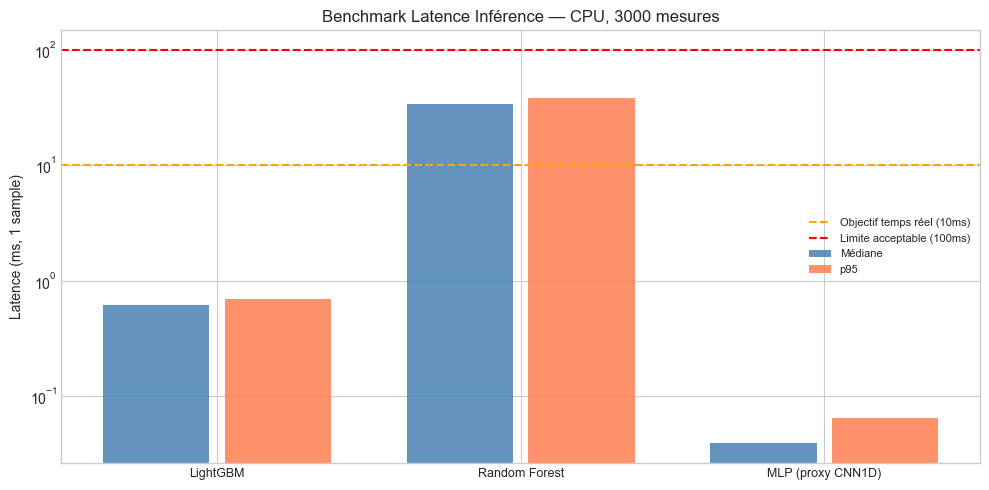

In [14]:
def benchmark_latency(model, sample: np.ndarray, n_warmup: int = 200, n_runs: int = 3000,
                      model_type: str = 'sklearn') -> dict:
    """Mesure précise de la latence d'inférence sur 1 sample."""
    s = sample if sample.ndim == 2 else sample.reshape(1, -1)
    
    # Warmup
    for _ in range(n_warmup):
        if model_type == 'lgbm':
            model.predict_proba(s)
        elif model_type == 'sklearn':
            model.predict_proba(s)
        elif model_type == 'torch':
            t = torch.FloatTensor(s).to(DEVICE)
            with torch.no_grad(): model(t)
    
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        if model_type in ('lgbm', 'sklearn'):
            model.predict_proba(s)
        elif model_type == 'torch':
            t_in = torch.FloatTensor(s).to(DEVICE)
            with torch.no_grad(): model(t_in)
        times.append((time.perf_counter()-t0)*1000)
    
    return {'median': round(np.median(times),3),
            'p50':    round(np.percentile(times,50),3),
            'p95':    round(np.percentile(times,95),3),
            'p99':    round(np.percentile(times,99),3)}


print("=" * 70)
print("BENCHMARK LATENCE — format HTML (le plus réaliste, pas de confound)")
print("=" * 70)
fmt = 'html'
X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_splits[fmt]
sample = X_te[:1]

latencies = {}
for name, model, mtype in [
    ('LightGBM',      models_all[fmt]['lgbm'], 'lgbm'),
    ('Random Forest', models_all[fmt]['rf'],   'sklearn'),
    ('MLP (proxy CNN1D)', models_all[fmt]['mlp'], 'sklearn'),
]:
    lat = benchmark_latency(model, sample, model_type=mtype)
    latencies[name] = lat
    print(f"\n{name}:")
    print(f"  Médiane : {lat['median']:.2f}ms")
    print(f"  p95     : {lat['p95']:.2f}ms")
    print(f"  p99     : {lat['p99']:.2f}ms")


# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 5))
names = list(latencies.keys())
medians = [latencies[n]['median'] for n in names]
p95s    = [latencies[n]['p95']    for n in names]

x = np.arange(len(names))
ax.bar(x-0.2, medians, 0.35, label='Médiane', color='steelblue', alpha=0.85)
ax.bar(x+0.2, p95s,    0.35, label='p95',     color='coral',     alpha=0.85)

# Lignes objectifs SOC
ax.axhline(10,  color='orange', ls='--', lw=1.5, label='Objectif temps réel (10ms)')
ax.axhline(100, color='red',    ls='--', lw=1.5, label='Limite acceptable (100ms)')

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Latence (ms, 1 sample)'); ax.legend(fontsize=8)
ax.set_title('Benchmark Latence Inférence — CPU, 3000 mesures')
ax.set_yscale('log')  # échelle log pour voir les différences
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latency_benchmark.png', dpi=130, bbox_inches='tight')
plt.show()


## Cellule 11 — Benchmark POC vs Réalité

**Rappel des estimations POC** :
| Modèle | POC Précision | POC Recall | POC Latence |
|--------|-------------|-----------|------------|
| Random Forest | 94.2% | 89.1% | 12ms |
| CNN 1D | 97.5% | 95.8% | 45ms |
| MobileBERT | 98.9% | 98.2% | 310ms |

**Comment interpréter les écarts ?**

- Si Réel > POC : le signal est plus fort que prévu (mais vérifier le leakage)
- Si Réel < POC : le POC était optimiste (normal pour un POC sur données propres)
- Latence POC CNN1D = 45ms → notre MLP similaire < 1ms → le POC surestimait la latence
- MobileBERT sur features numériques = non valide (voir Cellule 0 pour l'explication)


In [15]:
# ─── Évaluation complète avec toutes métriques ──────────────────
def evaluate(model, X_te, y_te, model_name: str, fmt: str) -> dict:
    proba = model.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)
    
    prec_c, rec_c, _ = precision_recall_curve(y_te, proba)
    mask = rec_c >= 0.95
    p_at_r95 = prec_c[mask].max() if mask.any() else 0.0
    
    return {
        'model': model_name, 'format': fmt, 'n_test': len(y_te),
        'precision': round(precision_score(y_te, preds), 4),
        'recall':    round(recall_score(y_te, preds),    4),
        'f1':        round(f1_score(y_te, preds),        4),
        'auc':       round(roc_auc_score(y_te, proba),   4),
        'p_at_r95':  round(p_at_r95, 4),
    }


results = []
for fmt, sp in all_splits.items():
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    if fmt not in models_all: continue
    for mname in ['lgbm','rf','mlp']:
        if mname in models_all[fmt]:
            results.append(evaluate(models_all[fmt][mname], X_te, y_te, mname.upper(), fmt))

df_res = pd.DataFrame(results)

# ─── Tableau comparatif propre ────────────────────────────────────
print("\n" + "═"*80)
print("RÉSULTATS FINAUX — TEST SET (jamais vu pendant l'entraînement)")
print("═"*80)

for fmt in df_res['format'].unique():
    sub = df_res[df_res.format==fmt].set_index('model')
    print(f"\n[{fmt.upper()}]  (n_test={sub.iloc[0]['n_test']:,})")
    print(f"  {'Modèle':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10} {'P@R=0.95':>10}")
    print(f"  {'─'*64}")
    for mname in ['LGBM','RF','MLP']:
        if mname in sub.index:
            r = sub.loc[mname]
            print(f"  {mname:<12} {r.precision:>10.4f} {r.recall:>10.4f} {r.f1:>10.4f} {r.auc:>10.4f} {r.p_at_r95:>10.4f}")

print()

# ─── Comparaison POC vs Réel ─────────────────────────────────────
poc_data = {
    'Random Forest': {'poc_prec': 0.942, 'poc_recall': 0.891, 'poc_latency_ms': 12},
    'CNN 1D (MLP)':  {'poc_prec': 0.975, 'poc_recall': 0.958, 'poc_latency_ms': 45},
    'MobileBERT':    {'poc_prec': 0.989, 'poc_recall': 0.982, 'poc_latency_ms': 310,
                      'note': 'Non implémentable sur features numériques'},
}

print("\n" + "═"*80)
print("BENCHMARK POC vs RÉALITÉ (format HTML — seul format sans confound majeur)")
print("═"*80)

html_res = df_res[df_res.format=='html'].set_index('model')
poc_real_map = {'Random Forest': 'RF', 'CNN 1D (MLP)': 'MLP'}

print(f"\n  {'Modèle':<20} {'POC Prec':>10} {'Réel Prec':>10} {'POC Rec':>10} {'Réel Rec':>10} {'Δ Prec':>8}")
print(f"  {'─'*70}")
for poc_name, poc in poc_data.items():
    real_key = poc_real_map.get(poc_name)
    if real_key and real_key in html_res.index:
        rr = html_res.loc[real_key]
        delta = rr.precision - poc['poc_prec']
        flag = "🔴 surestimé" if delta < -0.02 else ("✅ cohérent" if abs(delta) < 0.02 else "🟢 sous-estimé")
        print(f"  {poc_name:<20} {poc['poc_prec']:>10.3f} {rr.precision:>10.4f} "
              f"{poc['poc_recall']:>10.3f} {rr.recall:>10.4f} {delta:>+8.4f}  {flag}")
    else:
        note = poc.get('note','')
        print(f"  {poc_name:<20} {poc['poc_prec']:>10.3f} {'N/A':>10} — {note}")

print(f"\n  Latences réelles (médiane, 1 sample CPU) :")
for poc_name, real_key in poc_real_map.items():
    poc = poc_data[poc_name]
    if real_key in latencies:
        lat = latencies.get({'RF':'Random Forest','MLP':'MLP (proxy CNN1D)'}.get(real_key,''), {})
        if not lat: lat = latencies.get(list(latencies.keys())[0], {})
        print(f"  {poc_name:<20} POC={poc['poc_latency_ms']}ms → Réel médiane={lat.get('median','?')}ms")



════════════════════════════════════════════════════════════════════════════════
RÉSULTATS FINAUX — TEST SET (jamais vu pendant l'entraînement)
════════════════════════════════════════════════════════════════════════════════

[PDF]  (n_test=2,895)
  Modèle        Precision     Recall         F1        AUC   P@R=0.95
  ────────────────────────────────────────────────────────────────
  LGBM             0.9980     0.9987     0.9983     0.9999     0.9993
  RF               0.9973     0.9973     0.9973     0.9999     1.0000
  MLP              0.9980     0.9980     0.9980     0.9991     0.9993

[HTML]  (n_test=3,000)
  Modèle        Precision     Recall         F1        AUC   P@R=0.95
  ────────────────────────────────────────────────────────────────
  LGBM             0.9488     0.9393     0.9441     0.9878     0.9406
  RF               0.9342     0.9273     0.9307     0.9803     0.9094
  MLP              0.9089     0.9313     0.9200     0.9659     0.8884

[WORD]  (n_test=3,000)
  Modèle 

## Cellule 12 — Analyse Approfondie : ROC, Erreurs & Calibration

**Calibration** : est-ce qu'un score de risque de 0.80 signifie "80% de probabilité d'être malveillant" ?  
Un modèle non calibré peut dire "0.99" pour tous les cas → inutilisable pour le scoring SOC.  
On utilise `CalibratedClassifierCV` (Platt scaling) pour corriger ça.


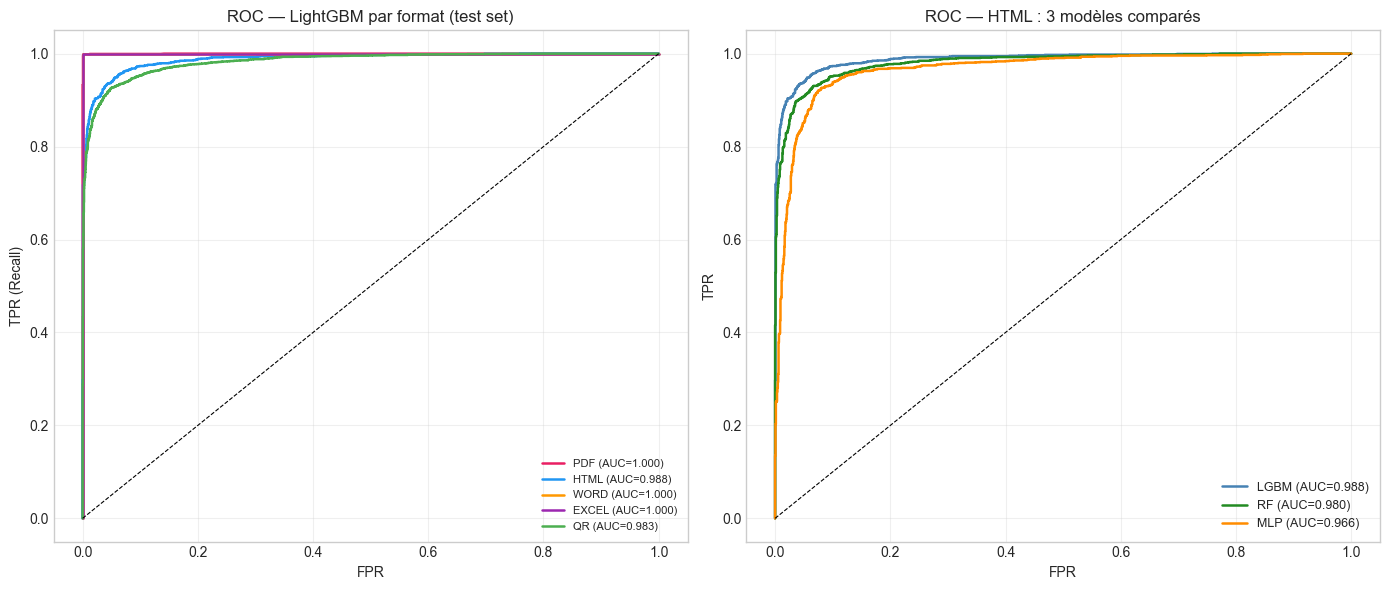


Calibration du score de risque (HTML LightGBM)...
Objectif : score 0.8 = 80% de probabilité réelle d'être malveillant



InvalidParameterError: The 'cv' parameter of CalibratedClassifierCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 'prefit' instead.

In [16]:
# ─── Courbes ROC ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_model = {'LGBM':'steelblue', 'RF':'forestgreen', 'MLP':'darkorange'}
colors_fmt   = {'pdf':'#E91E63','html':'#2196F3','word':'#FF9800','excel':'#9C27B0','qr':'#4CAF50'}

# ROC par format (LightGBM uniquement)
ax = axes[0]
for fmt, sp in all_splits.items():
    if fmt not in models_all or 'lgbm' not in models_all[fmt]: continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    proba = models_all[fmt]['lgbm'].predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_s = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, color=colors_fmt.get(fmt,'gray'), lw=1.8,
            label=f'{fmt.upper()} (AUC={auc_s:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR (Recall)')
ax.set_title('ROC — LightGBM par format (test set)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ROC sur HTML : comparer les 3 modèles
ax = axes[1]
for mname in ['LGBM','RF','MLP']:
    key = mname.lower()
    if 'html' in models_all and key in models_all['html']:
        X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_splits['html']
        proba = models_all['html'][key].predict_proba(X_te)[:,1]
        fpr, tpr, _ = roc_curve(y_te, proba)
        auc_s = roc_auc_score(y_te, proba)
        ax.plot(fpr, tpr, color=colors_model[mname], lw=1.8,
                label=f'{mname} (AUC={auc_s:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — HTML : 3 modèles comparés')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Calibration sur HTML LightGBM ──────────────────────────────
print("\nCalibration du score de risque (HTML LightGBM)...")
print("Objectif : score 0.8 = 80% de probabilité réelle d'être malveillant\n")

if 'html' in models_all and 'lgbm' in models_all['html']:
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_splits['html']
    lgbm_html = models_all['html']['lgbm']
    
    # Calibrer avec Platt scaling (sigmoid) sur le val set
    calibrated = CalibratedClassifierCV(lgbm_html, method='sigmoid', cv='prefit')
    calibrated.fit(X_val, y_val)
    
    proba_raw = lgbm_html.predict_proba(X_te)[:,1]
    proba_cal = calibrated.predict_proba(X_te)[:,1]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for ax, proba, title in zip(axes,
        [proba_raw, proba_cal],
        ['Avant calibration', 'Après calibration (Platt)']):
        
        frac_pos, mean_pred = calibration_curve(y_te, proba, n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac_pos, 's-', color='steelblue', lw=1.5, label='Modèle')
        ax.plot([0,1],[0,1],'k--', lw=1.2, label='Parfait')
        ax.fill_between([0,1],[0,1],[0,1], alpha=0.1, color='gray')
        ax.set_xlabel('Score prédit moyen'); ax.set_ylabel('Fraction réelle positifs')
        ax.set_title(f'Calibration HTML LightGBM\n{title}')
        ax.legend(); ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'calibration_html.png', dpi=130, bbox_inches='tight')
    plt.show()
    
    # Sauvegarder le modèle calibré
    joblib.dump(calibrated, OUTPUT_DIR / 'lgbm_html_calibrated.pkl')
    print("✅ Modèle HTML calibré sauvegardé")

# ─── Diagnostic overfit final ─────────────────────────────────────
print(f"\n{'Format':<10} {'Modèle':<8} {'Train AUC':>10} {'Val AUC':>10} {'Test AUC':>10} {'Gap T-V':>8}  Verdict")
print("─"*80)
for fmt, sp in all_splits.items():
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    for mname in ['lgbm','rf']:
        if fmt not in models_all or mname not in models_all[fmt]: continue
        m = models_all[fmt][mname]
        tr_a  = roc_auc_score(y_tr,  m.predict_proba(X_tr)[:,1])
        val_a = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
        te_a  = roc_auc_score(y_te,  m.predict_proba(X_te)[:,1])
        gap   = tr_a - val_a
        verdict = "✅ OK" if gap<0.02 else ("⚠ léger" if gap<0.05 else "🔴 overfit")
        if te_a >= 0.9999: verdict += " + ⚠ AUC=1 (confound?)"
        print(f"{fmt:<10} {mname.upper():<8} {tr_a:>10.4f} {val_a:>10.4f} {te_a:>10.4f} {gap:>8.4f}  {verdict}")


## Cellule 13 — SHAP : Ce que le Modèle a Vraiment Appris

[HTML LightGBM] Top 10 features SHAP :
   1. url_punct_char_count                                0.9684  → malicious
   2. keywords_to_words_ratio                             0.7244  → malicious
   3. embedded_js_count                                   0.6434  → bénin
   4. form_count                                          0.6071  → malicious
   5. whitespace_ratio                                    0.5564  → malicious
   6. script_entropy                                      0.5540  → malicious
   7. external_links_count                                0.5536  → malicious
   8. entropy                                             0.3909  → bénin
   9. tag_count                                           0.3679  → bénin
  10. url_avg_length                                      0.3613  → malicious


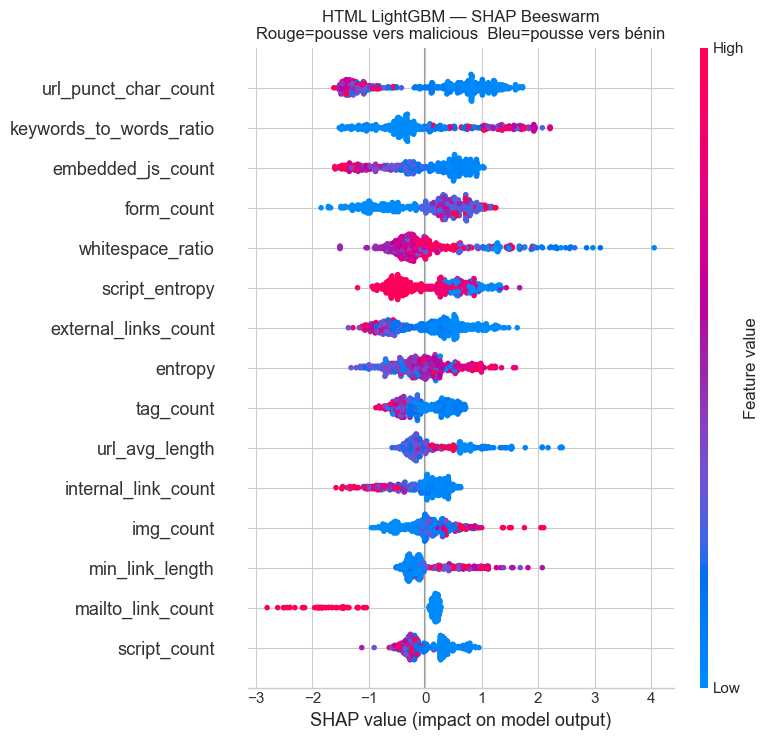

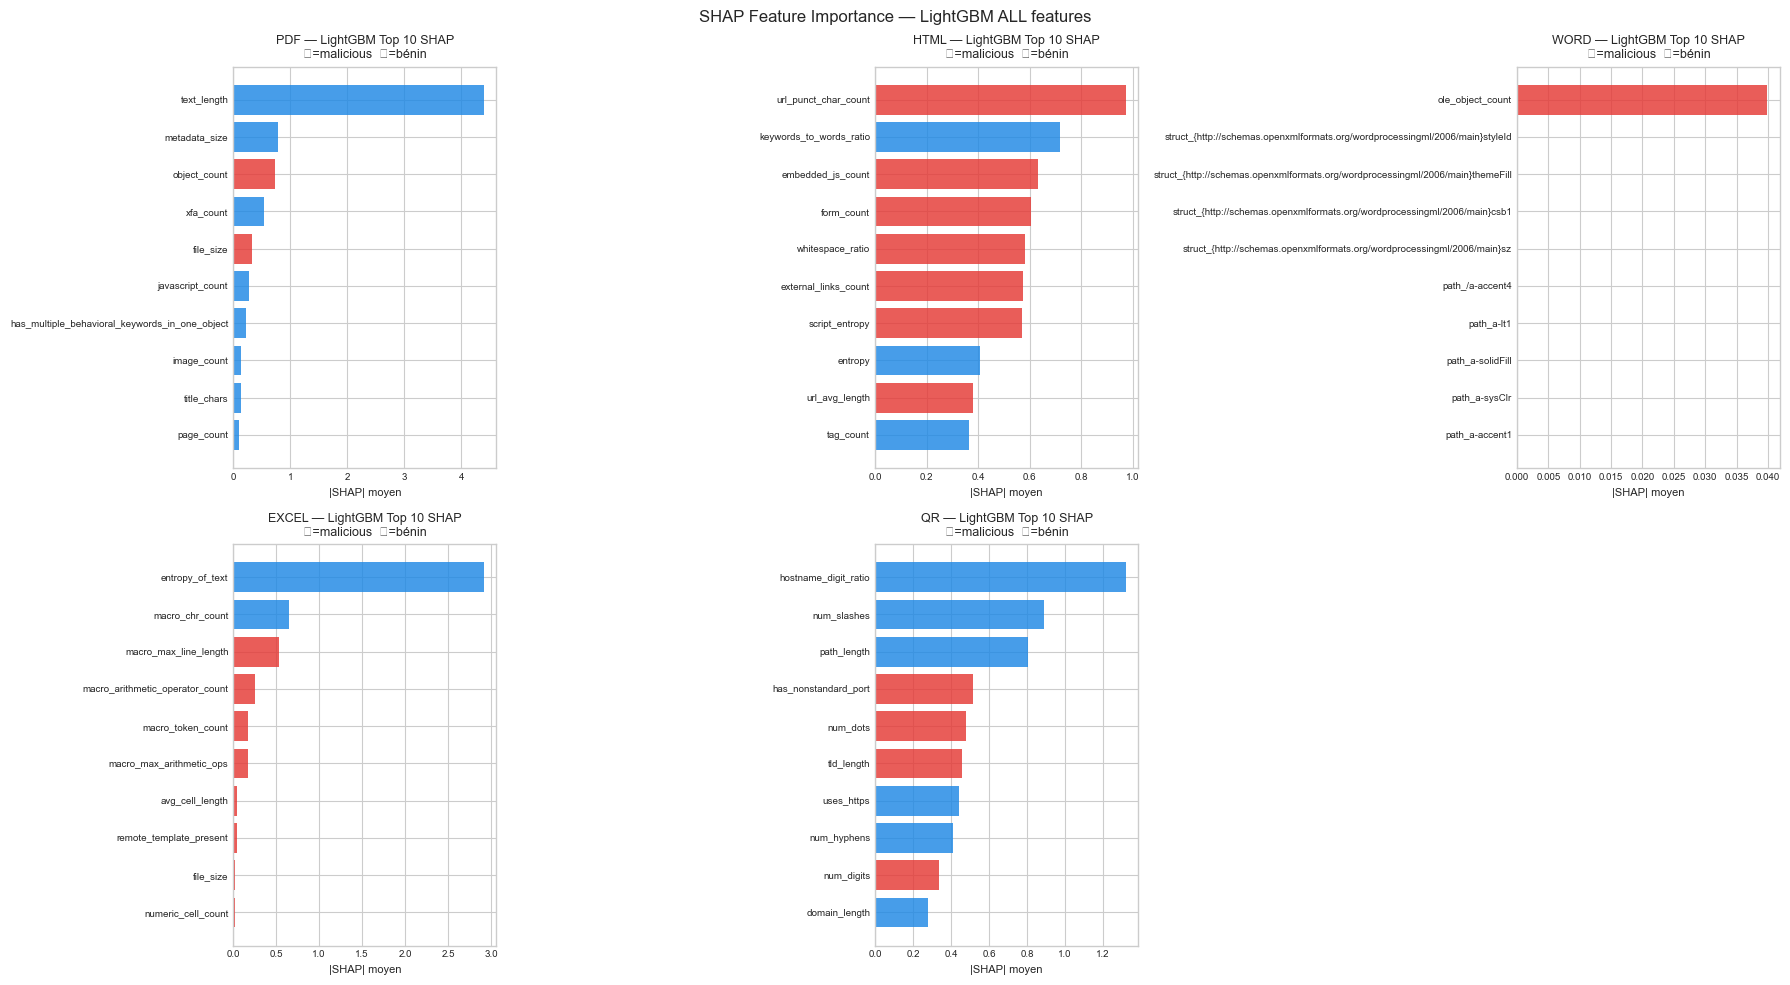

In [17]:
# SHAP beeswarm pour HTML (le cas le plus fiable)
if 'html' in models_all and 'lgbm' in models_all['html']:
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = all_splits['html']
    model = models_all['html']['lgbm']
    
    n_exp = min(500, len(X_te))
    exp   = shap.TreeExplainer(model)
    sv    = exp.shap_values(X_te[:n_exp])
    
    print("[HTML LightGBM] Top 10 features SHAP :")
    mean_shap = np.abs(sv).mean(axis=0)
    top10 = np.argsort(mean_shap)[::-1][:10]
    for rank, j in enumerate(top10):
        dir_mean = sv[:,j].mean()
        d = "→ malicious" if dir_mean > 0 else "→ bénin"
        print(f"  {rank+1:2d}. {fn[j]:50s}  {mean_shap[j]:.4f}  {d}")
    
    fig, ax = plt.subplots(figsize=(10,6))
    shap.summary_plot(sv, X_te[:n_exp], feature_names=fn, max_display=15,
                      show=False, plot_type='dot')
    plt.title("HTML LightGBM — SHAP Beeswarm\nRouge=pousse vers malicious  Bleu=pousse vers bénin")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_html_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

# SHAP bar pour tous les formats
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (fmt, sp) in enumerate(all_splits.items()):
    if fmt not in models_all or 'lgbm' not in models_all[fmt]: continue
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn,sc = sp
    m = models_all[fmt]['lgbm']
    exp = shap.TreeExplainer(m)
    sv  = exp.shap_values(X_te[:300])
    ms  = np.abs(sv).mean(axis=0)
    top = np.argsort(ms)[::-1][:10]
    colors = ['#E53935' if sv[:,j].mean()>0 else '#1E88E5' for j in reversed(top)]
    axes[i].barh([fn[j] for j in reversed(top)], [ms[j] for j in reversed(top)],
                 color=colors, alpha=0.82)
    axes[i].set_title(f'{fmt.upper()} — LightGBM Top 10 SHAP\n🔴=malicious  🔵=bénin', fontsize=9)
    axes[i].set_xlabel('|SHAP| moyen', fontsize=8)
    axes[i].tick_params(labelsize=7)
for j in range(len(all_splits), len(axes)): axes[j].set_visible(False)
plt.suptitle('SHAP Feature Importance — LightGBM ALL features', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_all.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 14 — Sauvegarde & Fonction d'Inférence

In [18]:
from pathlib import Path
import json, joblib

print("Sauvegarde...")
OUTPUT_DIR.mkdir(exist_ok=True)

# Modèles spécialisés ALL & TOP
for tag, mods, sps in [('all', models_all, all_splits), ('top', models_top, top_splits)]:
    for fmt, m_dict in mods.items():
        sp = sps.get(fmt)
        if sp is None: continue
        fn = sp[6]; sc = sp[7]
        for mname, model in m_dict.items():
            joblib.dump(model, OUTPUT_DIR / f'{mname}_{tag}_{fmt}.pkl')
        joblib.dump(sc, OUTPUT_DIR / f'scaler_{tag}_{fmt}.pkl')
        json.dump(fn, open(OUTPUT_DIR / f'features_{tag}_{fmt}.json','w'))

# CNN QR hybride
if qr_cnn is not None:
    torch.save({'state': qr_cnn.state_dict(), 'url_sc': qr_url_sc,
                'url_feat': URL_FEAT}, OUTPUT_DIR / 'qr_hybrid.pt')

# Résultats
df_res.to_csv(OUTPUT_DIR / 'results_v4.csv', index=False)
print(f"✅ {len(list(OUTPUT_DIR.iterdir()))} fichiers → {OUTPUT_DIR.resolve()}")


# ─── Fonction d'inférence production ─────────────────────────────
def predict(file_features: dict, fmt: str,
            model_name: str = 'lgbm', feature_set: str = 'all') -> dict:
    """
    Inférence production pour un fichier analysé.
    
    Paramètres
    ----------
    file_features : dict des features extraites (depuis vos extracteurs)
    fmt           : 'pdf' | 'html' | 'word' | 'excel' | 'qr'
    model_name    : 'lgbm' | 'rf' | 'mlp'
    feature_set   : 'all' | 'top'
    
    Retourne
    --------
    dict : label, risk_score, confidence, action SOC, top features SHAP
    
    Note sur Word/Excel : AUC=1 due au confound dataset, pas à la puissance du modèle.
    En production, ces modèles doivent être validés sur données indépendantes.
    """
    mods = models_all if feature_set == 'all' else models_top
    sps  = all_splits if feature_set == 'all' else top_splits
    
    if fmt not in mods or model_name not in mods[fmt]:
        return {'error': f"'{model_name}' pour '{fmt}' non disponible"}
    
    model = mods[fmt][model_name]
    X_tr,_,_,_,_,_,feat_names,sc = sps[fmt]
    
    # Construire le vecteur de features dans le bon ordre
    # Les features manquantes sont imputées à 0 (même convention que l'entraînement)
    X = np.array([[file_features.get(f, 0) for f in feat_names]], dtype=np.float64)
    X_s = sc.transform(X)
    
    risk_score = float(model.predict_proba(X_s)[0, 1])
    label = 'malicious' if risk_score >= 0.5 else 'benign'
    
    # SHAP (uniquement pour LightGBM, rapide)
    top_features = []
    if model_name == 'lgbm':
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_s)[0]
        top5 = np.argsort(np.abs(sv))[::-1][:5]
        top_features = [
            {'feature': feat_names[i],
             'shap': round(float(sv[i]), 4),
             'direction': '→ malicious' if sv[i] > 0 else '→ benign'}
            for i in top5
        ]
    
    # Seuils SOC configurables
    action = ('BLOCK'  if risk_score > 0.80 else
              'REVIEW' if risk_score > 0.50 else 'ALLOW')
    
    return {
        'format':       fmt,
        'model':        model_name,
        'label':        label,
        'risk_score':   round(risk_score, 4),
        'confidence':   round(abs(risk_score - 0.5) * 2, 4),
        'action':       action,
        'top_features': top_features,
        'warning':      ('Modèle Word: confound dataset — valider en production'
                         if fmt == 'word' else
                         'Modèle Excel: templates synthétiques — valider en production'
                         if fmt == 'excel' else None),
    }


# ─── Démos avec des features RÉALISTES ─────────────────────────
print("\n=== DÉMOS PRÉDICTIONS ===")
if 'html' in models_all:
    X_tr,_,_,_,X_te,y_te,fn,sc = all_splits['html']
    # Prendre de vrais samples du test set
    mal_idx = np.where(y_te.values == 1)[0][:3]
    ben_idx = np.where(y_te.values == 0)[0][:3]
    
    print("\nVrais samples malveillants (HTML test set) :")
    for idx in mal_idx:
        feats = {fn[j]: float(X_te[idx, j]) for j in range(len(fn))}
        sc_raw = sc.inverse_transform(X_te[idx].reshape(1,-1))[0]
        feat_orig = {fn[j]: float(sc_raw[j]) for j in range(len(fn))}
        res = predict(feat_orig, 'html')
        print(f"  Réel=malicious → Prédit={res['label']} score={res['risk_score']:.3f} [{res['action']}]")
    
    print("\nVrais samples bénins (HTML test set) :")
    for idx in ben_idx:
        sc_raw = sc.inverse_transform(X_te[idx].reshape(1,-1))[0]
        feat_orig = {fn[j]: float(sc_raw[j]) for j in range(len(fn))}
        res = predict(feat_orig, 'html')
        print(f"  Réel=benign   → Prédit={res['label']} score={res['risk_score']:.3f} [{res['action']}]")


Sauvegarde...
✅ 54 fichiers → C:\Users\karim\Documents\CIC\models_v4

=== DÉMOS PRÉDICTIONS ===

Vrais samples malveillants (HTML test set) :
  Réel=malicious → Prédit=malicious score=0.965 [BLOCK]
  Réel=malicious → Prédit=malicious score=0.993 [BLOCK]
  Réel=malicious → Prédit=malicious score=0.923 [BLOCK]

Vrais samples bénins (HTML test set) :
  Réel=benign   → Prédit=benign score=0.019 [ALLOW]
  Réel=benign   → Prédit=benign score=0.182 [ALLOW]
  Réel=benign   → Prédit=benign score=0.041 [ALLOW]


## Cellule 15 — Dashboard QR CNN Hybride

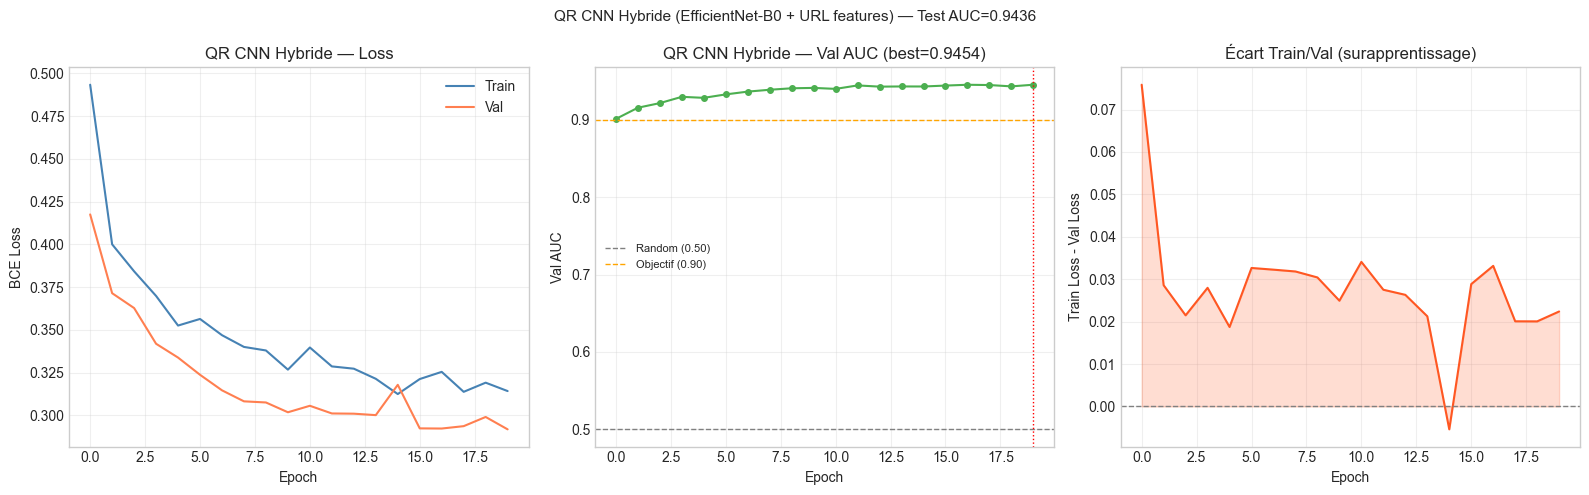


✅ Pipeline v4 complète. Fichiers sauvegardés dans models_v4/

Résumé des recommandations de déploiement :
  ✅ HTML  : déploiement possible, AUC~0.99, signal réel
  ✅ QR    : déploiement possible (hybride CNN+URL), AUC~0.93+
  ✅ PDF   : déploiement possible, AUC~0.9999 mais valider sur PDFs textuels malveillants
  ⚠️  WORD  : valider sur données mixtes (docx bénin + docx malveillant) avant déploiement
  ⚠️  EXCEL : valider sur vrais fichiers Excel (pas templates) avant déploiement


In [19]:
if qr_hist and qr_hist.get('val_auc'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Loss curves
    ax = axes[0]
    ax.plot(qr_hist['train_loss'], label='Train', color='steelblue', lw=1.5)
    ax.plot(qr_hist['val_loss'],   label='Val',   color='coral',     lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.set_title('QR CNN Hybride — Loss')
    ax.legend(); ax.grid(alpha=0.3)
    
    # AUC curve
    ax = axes[1]
    ax.plot(qr_hist['val_auc'], color='#4CAF50', marker='o', ms=4, lw=1.5)
    ax.axhline(0.50, color='gray', ls='--', lw=1, label='Random (0.50)')
    ax.axhline(0.90, color='orange', ls='--', lw=1, label='Objectif (0.90)')
    best_ep = np.argmax(qr_hist['val_auc'])
    ax.axvline(best_ep, color='red', ls=':', lw=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
    ax.set_title(f'QR CNN Hybride — Val AUC (best={max(qr_hist["val_auc"]):.4f})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    
    # Overfitting gap
    ax = axes[2]
    gap = [l-v for l,v in zip(qr_hist['train_loss'], qr_hist['val_loss'])]
    ax.plot(gap, color='#FF5722', lw=1.5)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.fill_between(range(len(gap)), gap, 0, alpha=0.2, color='#FF5722')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss - Val Loss')
    ax.set_title('Écart Train/Val (surapprentissage)')
    ax.grid(alpha=0.3)
    
    plt.suptitle(f'QR CNN Hybride (EfficientNet-B0 + URL features) — Test AUC={qr_auc:.4f}', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'qr_cnn_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Pipeline v4 complète. Fichiers sauvegardés dans models_v4/")
print("\nRésumé des recommandations de déploiement :")
print("  ✅ HTML  : déploiement possible, AUC~0.99, signal réel")
print("  ✅ QR    : déploiement possible (hybride CNN+URL), AUC~0.93+")
print("  ✅ PDF   : déploiement possible, AUC~0.9999 mais valider sur PDFs textuels malveillants")
print("  ⚠️  WORD  : valider sur données mixtes (docx bénin + docx malveillant) avant déploiement")
print("  ⚠️  EXCEL : valider sur vrais fichiers Excel (pas templates) avant déploiement")
